<a href="https://colab.research.google.com/github/braltoids0089/AGRO-BIOTECHNOLOGY/blob/main/LAYER1_GASTRO%2BMICROBIAL_RELEASE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Scale Digital Twin Modeling of Anti-Hypertensive Peptides

# Layer 1 — Gastro-Microbial Release of Anti-Hypertensive Peptides from Fermented Foods

### A sequence-resolved, mass-conserving proteolysis model conditioned on microbial community composition

**Part 1 of 3** in a multi-scale digital twin of fermented-food antihypertensive peptides.
Layer 1 asks a single question: *given a parent food protein and a personalised
fermenting community, what concentration of intact bioactive peptide actually reaches the
intestinal lumen?* Layers 2 and 3 then handle absorption and target binding.

---

## The claim this notebook makes, and the claim it does not

**It does make a mechanistic claim.** Working only from documented enzyme specificity, the
model derives — rather than assumes — why the milk lactotripeptides Val-Pro-Pro (VPP) and
Ile-Pro-Pro (IPP) survive digestion. Two documented constraints do the work:

1. X-prolyl dipeptidyl aminopeptidases (bacterial PepX, host DPP-IV) release N-terminal
   Xaa-Pro dipeptides **but are blocked when the residue following that Pro is itself Pro**.
2. Aminopeptidases (bacterial PepN, host aminopeptidase N) release single N-terminal
   residues **but do not hydrolyse the Xaa-Pro imide bond**.

Together these make any Xaa-Pro-Pro motif a proteolytic dead end. The notebook verifies
that *no enzyme in the entire curated panel* — bacterial cell-envelope proteinases,
bacterial peptidases, gastric pepsin, pancreatic trypsin/chymotrypsin/elastase/
carboxypeptidases, or host brush-border ectopeptidases — can cleave VPP or IPP, and it
traces the release route that produces them.

**It does not make a calibrated quantitative claim.** The absolute micromolar
concentrations this model reports are its internal arithmetic over a kinetic layer that is
almost entirely unanchored: of the enzyme parameter sets used, **one** is a measurement on
the right enzyme and the right substrate. Not a single kinetic constant in this model was
measured on VPP, IPP or intact casein. Read the concentrations as structured hypotheses,
and read the *rankings and mechanisms* as the results.

---

## Why Layer 1 is not a genome-scale metabolic model

The original framing of this project proposed predicting strain-specific peptide release
with genome-scale metabolic models (GEMs) and flux balance analysis. That does not work,
for a structural reason worth stating plainly: **the state variables of a stoichiometric
GEM are lumped metabolite pools**, not sequences. An AGORA2 or CarveMe reconstruction
represents peptide uptake as exchange reactions on pooled species — `pept_L`, amino-acid
pools — because stoichiometry has no representation for *which* peptide bond was cut. Ask
a GEM which of β-casein's 208 peptide bonds a strain hydrolyses and the question is not
expressible in the formalism.

So this layer splits the problem in two, and uses each tool for what it can actually do:

> **On counting.** The curated specificity table holds one row per *enzyme-organism pair*,
> so throughout this notebook row counts exceed distinct enzyme names wherever the same
> enzyme is curated for several species — PepO, for example, appears for both
> *Lactococcus lactis* and *Lactobacillus helveticus*. Every count below states which of
> the two it is.

| Tier | Question | Right tool | Status here |
|---|---|---|---|
| **A — ecology** | which strains grow, and how much proteolytic enzyme is therefore present? | community GEM (AGORA2 + MICOM/SteadyCom) | reduced Monod/logistic surrogate with a **GEM-compatible interface** |
| **B — chemistry** | which peptide bonds break, in what order, in which compartment? | kinetic reaction network over peptide species | implemented here in full |

Tier A's `enzyme_activities()` returns exactly the shape a MICOM community solution
supplies, so a real community GEM can be substituted without touching Tier B. That
substitution is the recommended production upgrade, and it changes the enzyme *dosage*,
not the specificity logic.

## Running this notebook

**Self-contained by construction.** Every input is embedded in the notebook as a
gzip+base64 blob and written to disk in the setup cell. Kaggle's internet toggle can stay
**off**; no cell fetches anything. Dependencies are numpy, pandas, matplotlib and scipy,
all preinstalled in the Kaggle Python image.

**CPU only.** No accelerator. The reaction network is the only meaningful compute.

**Two run sizes.** `N_SUBJECTS` controls the virtual cohort. The default (8) completes in a
few minutes. Set `FULL_RUN = True` for the 16-subject panel used in the written report.

**Reproducibility.** Every stochastic element is seeded. The integrator is deterministic,
and the setup cell asserts residue mass balance, so a successful run is verifiable rather
than merely finished.

In [ ]:
# ============================================================
# Embedded evidence (gzip+base64). Decoded to ./data by the setup cell.
# Provenance for every table is shown in the ledger in Section 0.
# ============================================================
EMBEDDED = {
    "protease_specificity.csv":
        "H4sIAN6Du2oC/+1de2/bSJL/f4D5Dn3GApGwLYnNN6Od3ZFlJ9HFD8byZuIZZAxKom0iFOkjqSQaDA73Ie4T3ie5qm4+mhIl24lnNskKCCKLIpv9qN+vq6qrq/3ot+Xcp9506qdpEEd0EQW3SZxdBjOa+O8D/4M/oz6/6XIaemlK4+Tai4J0TkM/us5uqD+lcz+Jb1N6e+XN+X+XkTf3UxpEmZ9AYZdwKQiXdBr63nvv2r+cxzOfprf+NLgKpkG2vLxZzL3oMvG9mTcJ/erGxL/2P1L+/+U0jt77UYZ1nC6yy9s4DfiXSRhP3/mzy8mSzoPoMl1M0izxMv8yr9/c+7h+MVmE/mWaedkiLVs89TIvXGbB9NKbZsF7qBf9LbqME/EVbg8yqFoAD8Frv//OTTKXusxULQYf7uXRYHg0rPrsaLBPpn4Ydnyodhjf+gRf4geRl/r0CIqMp/F0ukhJiMWnBKt42yXTxJ/HSZBS5igq1bp6V2Vdx6Rjxe4qzKHuM8VUbaUPnw7TTPxULJ1/qqpq8O+KrdKrSLs0+s/DxRT6+iO0Pbrc7z9PYGyg4y69aHoTJ3130Hf92yyYQZ0uxzbdG7lnCjMMRXlaXidwHSuXBWGQBlEn8UPox1kfbzUUprGn4+rHMHjnk9RPgihvLhSwB+Izg/bn5dG94aZekV/DS6o/SN77yZJMktibEUl4SByRKfweRGmf9yIME5TqX/mJH4FUP4UeTq59crOcgZTexJNgSoKIuIx40Yy4OiVuEvMranePtv7xtx9+ORq9fnb808Xbrlv+2W7944dum+65y+wGXshFksRQI3i93wn9DEQdWv5fC3xnn/je9IbMvQz+H58Pzs6hfBgGEpC570UpGf7znOwfnv90eHiCD/0SdNhbXh3+5S1pKZ0JNGnWpiTo+l3iXWHxiZ8Gs4UPpUBtmbiDRIv5BDv8eqWf+wRQQiZ+9sH3q9ayJ33yAeoSf4CWd1yt46od+O0HuXc6XrTsQJ90pGt0L4qJN0njcAG9yyFHZvF0MQdEgjDUxgOFGUGSApS8kJIozkg8CYNrL4uT5R41Ka0eJd4tSMDHYM5RRVr/jAJ4dcZL8FPypHnMn0AjshssGUpoGHMYqEO5M0iBaPFcc6GUeCEM7uL6hqTx3G8ol9x476H12KH81ZT43etug3zlI5XiQGU3fiVspKCtlIorQvT4PWr5Y5fs+2lG3kXxh4hcxQkJspQ3AXqoknapvkEGVUtFzdIbfCqLRYXC5W9QNeCU6xBqFvGXQnfPgt+g56CQRQgX9zvTGy+IQPyHN7wtCPIlSZdp5s9/VJnVb7xus8brpqrQYhgFP5Lh4HxwdHE+GpLB8Hz0enR+0SfHh2en7pjkxNYn7vHo4KmtMNVUnO+/20N6JS2Q0Gx5C9gfv2SsvQdEa6iOSl1N8O340fiWtHCCgL7gLwL2NRvYt4+fjJl/LAuv8uUgJXln8M5sQ1eNRiPeL+S9lwReBPi6IvdoI7aNkllwdcUZIxekGnj5HP/vwIM0ggqXlLaNlHZc8qVwCWL/HlzSy2HKdbQX9JUz1l+q+QfSxovDh9DGxJsGYQiguvHD9z7MaaAyMlt3OD10up2cHGyZFAxHVVfJAD81aH9OCqPoJpgEMCNejpxVCuiPw9vBn6ONbVLGkHJecFrpSg3vr6lorbHdrutpXLiAXCrh6pKTmKD4Az/Aiwho8qkP4lKKdOJnSQA/AfAiAANHXbdOQV8p74gHvRqgAcBFSS1hGeX9EkQ5N7Qp6kwAW7CGgvQGxBToqflWaH64JC3QztZxAR09R0LD6uYg6hOg9+A64pevknhORmikIXWU0tamzdBVzGboWkozdBW7hK7AXr/hZfm8zxSdOY5hC8iq9Ll9MDDt/ONRMEuGJ2c/ayplpmaV0JUx24DRR8AkNMyu3dobG5p0N3nnf8Qp2J/F/PuD8KmuATRvZTNOu2QYd1BBSFIxd2EZfSg0iKbBrRfmeO3M/OvEmyGGy6kOqggWOowtV5LSHTgfDZz9+yOQGU4zAmGyabquq6xEoEDSFgSqTNEsTTE4AvfpK902dCP/QAAefBoAZ344SRb+9F0QFOroZBFeg9rK51FHN2vzKKvPo4VyvWUeXVGuH2cm/VzU7m2D7X6O2q1d04xgugbRVVV9B8XPgaKkR4IkbpoIN8BNtZsnSBNktZwIOZ5WX1QYv6Zh6LbCETgGffWZ/UrPPy7H52fnZ/dE4DhLoHcLWxAUrGQOfRqECDjDNmqznwWv7MuzYIMZi5+6aSj02ej14Kyf4267Fdu/GI/OXl6iruGF/2LHIoJujKAbd2u9sRFjWM4HD/4TbUPjbIe7L2MKtLRm7GnNU6NhykooImmbEsoUAy03AKB/+4a6qqrB9OQeum+anPtBBFMOisoCbHZSieE9fPuWqXEQMvjH6JgZXUVhiEaVqQ6izTa0fP6D+kuwYlwnfXM5FB8nAlgAUUOVgcUMSt6gC5fMAlGxZdgpa7hHTzrQA3PARkj8j5Ll1qpuB1F+07lFmz+UCiEwxpH8AFaj/bRwD6R+St54Hnce/94hkziapRQHBOCK6uQiyhdriFSD/IHyLT7Yi/tHp8OXhwfkw41fWIhCIK/iMIw/YFnczYEejxQ9Gn54hd8Alb92XYDiL7+6b79wNO7Vup7bYtimq8T3y+5BjqpgWrh0iEpa/EUwxuR3ctHtAvNI3YzF1IcfxtzVyA+8w8SjRePxxo7bFi79lBQrb2AnhmlMiuEKrnihVbWw2/Mfe950yZmbajUfWunKPxySUtihlrnviTv4BfrzoeQ1FksLAZ+2SOqh6wzeCayETgNufGTSwgN3aPHHQQ57B67bGb0mY/UJdBVULQMJeFE4rtYlE/1aotP8SjKpLJqVSIrxKZcR0XMxDRfcRhqERbG3nSjIktiLYEqZ+VxCWqKfswBmk2WbnC+T/F73xs//eh4u879Gob/BbabpdrOGb2647lS0J2is98pwQPfovXJ+Nl46vVf28+OhstWXJlipoEbDZo7tGIWmYpvAYUZOlKLokihXTfWtRNnkXbOcx6LHHdPtmG7HdF8V05nNCp5uN183mP5nMh0vs2S6g09iuu0uEcs2d+S3I78d+f07kp/RvDqqW82eJUOx/kzy44UJ8mtwR20ivy3eKMswdly347od1+1M2i/KpD2hrjJUz206OHZPHtn3Z+crXox1VXqsMKiRCpTHmK3ZSHVM1zT4ZJajKPTwbOAywXI59R2z2pfSBcgcTfatHzOM6IFhwxinGsH1Qn/xLsZ4C/hpoOc8hw5hLEfTFWY+HdQp8YTHmuWOeU3Xa+8hwu+78pZ0i5OxficI9OrrOAefUCgceDgX57SGViiz4CKEwO+dC8/r58FVKYovtH46hRJTMo/TrIyhErG+3CWdAumGyy75CfnYi+SiG6KvEL6CqAGhkyUWQ3mNsg8xOR5ckIlf1HRGvBQLBBkBCVifCzihfw2rBR+bFwtKymakVQ6OR5Cmw6YRaiPxwsXIwyh6grH/WFq6PgPwqRHqLJoKpf5aLK8M3rqyPOWTpAcPA1mWFAbUBAME71udkgPiJT6PQ67ojqqU7jVx+zqd88jzCVR/3oY57izn1/hqRWy4XIPcBcC4pVR2BM16OUn4FG+DHoB6ewlMMvili7djg4QAexMQTy7DE+j0OVDgxBdiXL1BZms+A2LL87C+diHU5CES7ZFcNcp/r8Q7r8H9xRu7EfpPIDBOflRtp6JuTqy9V0yxtK1knVNjEZ2g2Y5uOEpOz+Lxkp4/2+No6/rjkvKO/Xbst2O/Hfsh+znKo7LfKVdO93U0xE8fWTk1VREbqerdDj1mGtRBp4L/GI9rNnWHylSn1YhPA+bj2qhiMbumJWo0DoPreCVgox5Xf8qZ7xSZTyORf5uAWllEZgAVrhewFmncmQF6MYyY31sYOn1hAnILhyMR7BZaRuILO0aW5CLcfSX+nkcx10KXq7DlYnyl8GWMD5HCQ766yJBgPvdnAXAAdM7+4bPTs8O1MJEnVZwIDFlPGjK+N6Xa69AGIxq6HykIURPzjQVJRkpTtPW3/zbKjm6T//uf/yXQteXP6QJ6A4D32nV7I9dt4jNjYwDKnTFfIG25DSPXmIpdnzxunTvgclzP4ghAbWh1lWZf750aKoh9hWCBnh7/ZFWIiWWppqYXX1XDYoph5cAWRZTA/my1xtRX4cyUB8J5h9sdbr9i3DrWCm5N5dFxO6KuoaqWTd2R+yiwVZ3SGjHoWIN6qNwrDnhldDApPTaXTMy2qs5qcZVgq/DrBigNT6GpYQACW2xOqyqQO3RU03wKtSxLJWeL7ICDd7MRkytLq7ZM/i6QwZpJ0yON93PaGMlGjvS+27youv7Ypb+6X4HxsHe39UCFHcaVfsmmCHCvZ7xHpUsImNKNXLmzP1WDlxT4e3T3yQLex5dr/B9B4PsyuFRdr4MLMyGU4OKQ6Lm6aejb9+wJ+S6QxO8vkHRw9Ejr60LdfQiwdrK/k/2a7Jsrsm+syr76ebL/CjeommOu/b36o4JLNNMWANC6Dj0GtVBR+GZ2pqlcIVQMw6JD6MWMB85fnsj6oKpTMWOYhiMbd6q+n0/EtLCDuZa4ahxXcKgg8Iri8+vLrUf8yYMRdMb56OBwLCQGuiCGEeLriZU3gNxiw486+TiKBdO/fNkokfpkg3cJHSzogOgURVWOHuwLWn0N4+jaxzVDD91I5XbxHDPFFr6+7GuaL1LcE88deSpVu8rWVU4QlgZktWk1UKX/g/yVvFBPyQ/oIznqeOHtjdeRRuqv1TDR46il/rX9o6pq/eJP0K8a/nTs4k9Ntco/dSb9KW80BQz1Tm3dAfVwm4NFCH8OPXF/Cb3P1uA+F2c7IO2A9BUC6Vysm1sIpPNHdk3qTCt0N13sXDNti6/NGLoJGFMuZ8HcT2pAUvLFcdXRtNqMpXDbhynMZPXr+1QyYFd0ti1L2uUzYknnPKkhlRcj38IRe46IVe6xxpPrJednBYjLNZTuX77+VRQBzxtgojsBmuLNIoEb+Y8fiFb6E0rOm/W5uuhlMkbhYQA2sN4sSK+89zFufy80SdIK+IIERs+0KUpYDcFFLE7+0gR6M0g4aNfBDXLZrgJ/vKyDjpYy9oevGRSujTIy6tqP/CQfauADvl/uKg90KgN6ojgqsN5gxaeyVrtdgirJ7ta8JLbWX120YJZdX7Sweq+cI/351lROJbVJXZLzgni45IXPnmA/jQ12AN4B+JsEsP4HA3hIXym6pXINefjYE7smAuJUtasrdIgLnzZXljXFYNLqxJBdqvl8DuiXg9CGDKbtCdjq8+UUxLh043xGDNqQI3xIoeyq5E5ZstgtPsXIxPUIO2CEQizqP0A/+xklR/6CA3MQetUqeLH8nfgzZIdfjo8Gb7+NMIkGNw90Qw96oYc90OK50+AReMFtgiKCXvyVcAes53pYQ0kHIIRqLVBXSrO2xTcEaBedGnlJEn/gWOUxunjDrBqQyhTAeohAXvgtTjAgdjVX3CjiyORsV8nkvgoyBwKTAUo/AvqBzabx3M+8MCzWu9oYh1AQYZAKXp16yST+uPRKjsPLE3hOGAN5iKeIleDhzZixLd0gf6UJ0yXn2Ewp7R/mEcQFG6jThxtgX54eKIWunRaFV7aHJLNQmQaR9muyLBOVade8aJpR96ppEmkJwuGhErq+jbRyxih4it9f8tTnKxp5ord7sdOOb3Z8s+ObL4hvLKXOL6Ze/24bn8c3A0yQZVrc4THgetHxY+lFZULa4+dMMzXQbYvNUqxr0WNdLfZKGZquyUEceqEl2Ypiyd4NXRVeD8vQ7Pp1CvKxyLz52jLVFg1qwxPAH8+bf+EMN6D4vg3rXqJIkGSRz5S7KEM/TQGs/scMdXYvvfUSRAvnrMODt9/GglgTZ0EvklacUN4DxL9C4EAXYAjMIL1try2Twf09+KFpqex+K2XtDctj5agAo9wxKu21NbS1YEiw26VcWACdrb5FIeUcaph1bdABSVcO/vPA5oDTLl/883hwUiHuBsNEW/wwAUxKyk82eBHPgaW8W+i8lGq28MurWpfRAY+x5BiyHFMkcVZUkw7YJdQvb0If+lREWTDdZE8HvKmy+UYGbDUPVVFb0hqwvHPgidpNgAA5kKkyZzkRyonX5bBYD3oXaH9Ka0mBq5zGRVKqZ0c/XYxeH/OkVNWXbyBpswDKJIY+QtqX+qlX9k3uPyiNd3kHYPlbg08B0bExL31umvPs2JjVHscfxxjPkWivJI++tzKwydWQ6wTRzEtg/r2FwcdH0R0AbyOLlGdbhn+dNAiDKS4aXPup0AbcJqF6+skCVaWY7pJhHozH+Ea/3zuvvbADM4feeR5G8PVFkHYMSpgG3xfwHfcQMh0u6PzP3zswZ3cwMRUz+J+/d3DnIDPhgsn/zO+wKFE1voNQ7ChUoQxVz9/JLxi8dqqRX8NnVTP3tuQJhfcJT0KNw5bnpV5RDJy6IqBa0kZqTjA9/mGJD2cbSeU0IpGULkhKaAX6o5BUn39ayj3IasdGOzbasdGOjQo2MgQb8aw1A+MR2AiMKvHJdmy0Y6MdG+3Y6G42Ok+WKBMdoAzF0qHE87ML9mAuUov9LLjqO4aymWpRkaTYofkrinwIGtNrKVEHFNq9nMeZuC2PWCyyDavW07HILuzm2YVT7q8oHyfP+P3ttaTD+WtJa8w2EtcguYbBeON5lBwtU/FnwUcvzwQVffnZXe7YbCIKgfbh7k5o8RayIa2KLF76QdhIFcXS7cveWeO67TpJ+B/Ry4BMskoUm4/22UAKG0asMb13c2I6pmw46UaRd6AgFnr8w95+sA2X9R5+qnhKRoEnVeDJRjypn48nKHsNTzuB3wn8v17ghxJ3x9eg6OxDn8p8vt+mLndt0+H52f4nzC15Tm7AAhNzi6F+3tyynp++Vt+tABKTPh+O8+S2+FNM6mKQuJogwerip2dH3xSwoAt60PYeNBoX77agawOOeB77RhhJEFoFzv3Q8qDhaQKFZTRjSG0+S0l2mwsp770yn7sjdieGDLUJOyoVj3OsqH8MVnbSv5P+L036O0P6ysGkbyj4w0+Qe7uQezWXe+tBct8Zkh4BJWDmT5M7VCjRhzTv7KJ7Ka5/i+u85ykRFiYuCkZ1SBxdPDv+6dXJt6Vs+YseIgNRgUEdiBDogB40/mEIAXQ0I+J+CCgFnMpgkBAgRmkVImKs+J/ycDVCRN8AEbYBIqa0dQMl/G5sWN9/dwhaaYbxReqAtIaHRwN1AGqUYuPxWvBVHXwCRJwCIlYxNxiPYqPbRm2Te5F4kJKiERhBsUHzktvZI6Kh90Df6lCWA1xi7PjZN4cvxBU09F+Fp7K7hZ+t7HEipT31cTg3njG74Yig+0BHiP7d0DEk6Gg5dDQOHUdxNISO9gnQsZQSOkoOHf2u6UWuhpBs/kdxRhY53G6nc+/jG0wfV2b6KGPxy24Wsj54/vqbknUeDJjOvTCsHLzPw2XvtRfm6cVEti9UkDaZ0+2HoYS/soIJD59J0XzP4urV6XqQ3yabvRi9LjlYGb3fpNF7EEY2HK/FZB8wyvjdGNFB9RLRhLVYGZchldPhvjt4uJGuMzG7MAsMj2OmF/E7ilqcWoexv1IKI74xAt6Pf1I63BTMNl2pKMh3Q90xXY6+ut9n2JwCj69VhUGWhTzbHb/OPTV5/m8vk1PR4UoZRnBR7kcqfEoi+zeCr9v+5deDw7OX7tu/fD3xudUumeFK7u+JCGblG3O8KkGlPD7QIz0e0pZc96A7eg1ZIMolKyzn1o8WYRbwOLUyMq5K+J0+IA6uv1pgQxbvu/xsHO4gLWRVstJ6CsVN4oMhsI3Sg2LV4eLS4fLS4QLTySUGa9olvxM5x/NQL/cSy5ef4WUMCw4iv0xayHNZ9MpoPc2unb4OuN0arSfw2AR7lbq6rRgqh736WbA3ctyrfwzuG+pewB7mgmkDKeBQ5fHHmNRssgjfBYCU4dourpS0ijXFdreA9bOfLo5Gx98UrD3eB8ty1fkTMN6v4bm6fnfYPTD3OAAbwEtEdD3QA+BsfdxIq9jjBjLVFoDj4PLkUhHFWwa0ey/gcMm/GzhqA3D2xXRpIm72P2W6tArcqDlstD8JNvsFamqKZ7KB+qpFlBIYL8++MVDUm4tCT9dFiutw+c8Pw8LWyG73PoPAUwDmuXmvg+roAD4ldTdJurzPlMvq3ZKuff9dfq5FCz51qJ5q6bZF8cuDZdwyy/OyDDCanFLGHXF0jKKpJpY8el3LsjJ28mRGqmUXS/+l0TR29nv8kXseK1O0ZuzI2mE9P3KV2QOzfVzwDMk/o8G7ktCS64cXIiMyz20s7AYQTffs9PXo4PCA/Cx+jfwANwbxu2BMhOoPGJSyt/zi8l1d3/jRMWsHxaxmZZY2S5RHxqx1WFsc0TOW9MvV42Dk02JKcFb71H+QFVL5YBlxmE8rPxCm025K341HzTxuRu6y+bQuch1abtMAS7G8Z7sc4u/x+wBt4vuKX/PacbOL31KaT32xdGki5Syx3fDk8C+yZtuOaTDr++/WM+wPTtxDFxeMDQYzID9G4KG845jW6pEBbHeOS72fe4R3NKoCoGEli/SmM4mTmZ/8MScbFIcaDO48z2DlMIOHJ3n/Rs4weKTDCfbuPp1AGNUiV0fRoXx/abDidQTjN42baRzvLYcoHxwo+6bI2SXSRc/2docb/GmHG2jy0S6cTe8+1QCD06XcdYfuATKx6hj8COmDh1s5xXHRVbI9viprMMcok+0Bxzdns1SBp582ZNgTGZDlPHxVpXsEKwq0dv+Mey3ci51CAdM+ueIDB/PbLUoaagTTGLocVe7rQpjAZM28Cdyfztvdf688fOmmRHxN2YK+sFx8XvXUj6phlKn3LLNf+8ku8+81/6nhznXpAc2y6t+rXH46U/vHEggRSHcn7LMECIEU6qn5W+4Z14x0m+mAInd4+HCLjJXrWGB6CZ1MeOnBFONuB9ux5NM8nZpdVqpCqm7VVnydAS2ITDonoExkzphpPXWbfufSPfemSTxdTkVioPoiWmNPAMjPUHfhRl09T4I42xCZ/e9/r1ZhEBmnR6Pnp+Whn9yX4X5Li2ZiduCHMXCc7a2tf0krifmZAfVVkg6f7uCx/tphArOg0wOFFuwjntMB9Qfu/I460oEBqB3I5wn4V1c+360AdSyycGV7VG8OiioHrsl1KHQU+QyKprxhmKpBJOzIN1SsaRetJ7i9Qj7K4kmbvrinBNWea168M4zm4BBTb17hNuveSAD23UYUTNKD4SFpZVhcxidoW2V08Al8wDQld9EYuGqn8D39ffGZny6kyKl0josEFszQa4kqwNAvnC4dORfuAOz7puutSuralLfmWN1QQs1vIzvFqklAHhgxXKgECs04V/JOTs/L9DEXdSsZUzOglfw8XBQuzpwWcGXv7ZeeB3CvqduaF/NQr6zssrpnpqljcfAq/2Z5Mgl0ac9l7dypkrtmKhruN/jjSesCH1Kf4FPY4aK/84f7XD3nwB2uunEexfnS2Dq6QW5oTXDyPPf0Lskh5zcL6FRQF6ESab75zouug5hHEkRkxPNzyBdG+Vo0GBUJrypcfO+lsTh8OJhmaK7keXqEWVKtNqKmXysL1xbrrytUo6PODVAvl5AjkNkFLivCj/XH4elJ4s2W71DVlR7FKJ8jXMmEa9UNLdax2vAIJ3+eWtEtn5GuwW1OmythR/5izUIhDHQlVsvVD5cMVVnNmEjUHx3bqd+o/sgYk/3byIHbDRw1P2H4YJ+wU9uszovRFRtDIv4fDgzfSnClAAA=",
    "parent_proteins.csv":
        "H4sIAN6Du2oC/+2a3W8bOXfG7wv0f/BdW0BZWLL8IeSm9PBjCHK4/CoHRBEE3qySGk3kNHZedAv98X0OR5Ilx7vvtgV69dpOZI9mOOTh7zznOWP/+/q32d2HD+vHx/uHzez75v7rt4en9/e/zuh1fb95v7n7sp49fPt0t7l//IKj6w/fvz0+fHv/eb2ZPd5/2tx9fv91/fXp/tf17Mvd0/dv6/bO7tuHjx8f10/7nx7X//F9vfmwnv1l/e3+4/361/dfHp7uPz7+/d91LN2+v/25aDfz54urq6vZ0ZHb9dPdmw93j5jN7Pbh8ezp7vu374+zxWI5m7+ZX84W56sZXqKwQlhXvBK6iGRTSkIknaN2xmhhZMDPIYQsuLCBG917yUIOyZbqpVdee5esD057b3PIvpTivbTBizKokkwxgg3Mm96IAReY6ovwMouEIbLNvAhne+vxaUMahz54fFnvcxmk9yEVi0kFjGN98cGw4qsPkQ9eByatrUH4YpUvUWF0rcsMt//nKXRnN8ufzt/cXP10/o+0A2erFX6cn89/Ov+ns39tU93i5G2b7Lu3+vm6a7ru+nDdDV23mi5ra93i3G1b7bu3J3HYD3B5QwOc7we4vqB5XLYBWvC2J1dtW/jevd2tbT/I/Pqa5ntzsR9mvlrQgdVNG6iFY7u7ZtsC8u7taTgOI61oAovzw4oW5zTBxWIXCgrk9vTSLUJ5PNzLoRYvhppfvzrUtu0KBppWux/lCqF5c3WYzvUlxWeaTENruzt/2+B611Bn82PWF7PjQ+zz13+7e5PmrwE/3wE/X03AA0WvTR8UdlIU68CfjVIWhluKIpURpjhhk+FaJZEAfmCD4NqEQTCkRssQXTCzIoLpdTCCF59ErFZVKwJGs8ZUg+2x03lMiGj7NBihdM8CLvCDVsUFYVmV1QsrY5A1WM6qT4qNtRZvVQ41c+aTTByYeJqNS8LkPHg7ztqM9/FctE253sfzgrZkuWjxbMvbtrO3bYHv3h4v9mSEi+XpCKuXI+wu2rYQvXs7TeUZjWXDc/WMxqqhsdwNg8lvp0u27962cO0vXREPq8Pd5+eXLVOn+7fobtv52xZfZMoUtsOdlzT7+fJw53lLwPnVdOcW6e3umm2L9Q6pxTFSF7PjQzukFq9q6GKvodeElHF5EH3ZSadOQeRqgjBuYNr5ZBDALmXZGVFKdMwJIWrCdrbzmSgsC1GMzoVz01doHKDUjogw0odq8VUDsgGw+pGHYjBI8Tr7bF1EQFLGQC4ZgxEGIrbIjB+MxbiYRbROgkjMK9KIzNKYOLeGHvcajB918Di9aF8LwjxrsTHHobmZHR0xd1+/vlZa5qtzhGUxn82vVki7WRABgQ9ex04YLpBjCfWDmaohVRW6HkF7VdbVipzwhVntsGoLQauVGc9YicmzoG0YA053uXhmUhdY8MCIxd7j0yaJMHtvjEN5ykL7rF3WLCnhc0KMsmAobBlRtoInAKxF8h4BziUUnMEKFmxZd1RKry+Xs6MjrZR+vvvw9PDp88Mv3z+/WPb1DdFwhWUDi6uZ1QWVYTDKcmhDYSqPNVnUQIY8ThZJHhLzNpZaUHmNz14oDqVA/TOjcEp0LGC3NEOqG+1ZkUZzQsKhBhbLM6+QF2tlNwjSFi+gmKwLnS0RYwEiwSwKNwdH+PJDryOC5HyGHonQ9Xq2O/qcPq2uLG9eT5820HZ3zbYNhbKHyZ5Uu6v5Qc1b9ZzqQVvYlk7etqVRmaUVHSotXfpc4ZqCrKa0b+vfTqdvWwTevZ2ieZj3ZStFB82ak4RdtYtb7LfT6dsWfdQgxOxw6XlbMunMbsnztuRdRWwx3tIF2xZlyAXrxPv+XwYGQOaLG+D9fIBtPt3D9m0e7zdvPjxs4NOe7jefztab//oNLrB/+PJw9nj39R4nzOYX51eUJChFi+vrGV4t9woGRDmZGHZOsWBhsFJ1CXsL7GHACtAZWc+z05kJx2IMQjBm4YuEZIKNCnlshK3C6zE4mTlKT4xaK2RQtioxB3vFTAyhOrrMDSnqCvRN6ax3JrPcjQkz4Rb3sCylmCobsHw2CjX2jjGlPVjFLbjMDCMIBonjCvfKitUxphEz9lkKji3voVeADadbmDsmS4zM9jFWxWPVzkYyPqy3VvFhxGKBva58gHOUnhvvLKfEHGwIanQs94OMBUVUypwsKrMfkL8SM0sDQPeMqwhl7Xqo98hlddFwGVGvuxxLHjgJZOl7MSgU60pyajjMZEKIFHNeyV4wrXixWFeBYmD6vdEKmYrLHYdV5dqBBTNQXmk4HC9R6QsPYxxVkUkh7zzUzEk+jtXGbCDXuvO+5OhE7iXHthrZwwuU7KuOVZYkiw0y0L0tCgNTVShv+9BxXWPKhq6wERkfGApF9CN5FYMYQVYYaQj8sqky4B5htE1qAxIMrmv0ooaxhx333KHiKc1tyUBLQMIlNKfymFMoZXSi4qAbXXWEVhY5mSZDbgiauT7jDnAhLEJMUENtcDlrA66MKQHbHMEg9Jk6iOroSlSfnCt4zdgN71TqLGFAVJWB5RQN+LF2bFRF6IqKDOqOumwghpD/wBiqlaoFEeMJVA1VZI9Nb7dDLqAH2VNVd1T1FTnTgypxoMoRVXlMRJVtVEFx08CpFgzWgKrsYxwk4s55owq7DT9NVDkzUZVfUqUOVOWCm9HA7ECVHHZUMRvFq1QZUJUwcXRYQqnERQ+qpB2IKiqLUnuZ9lTFIrlCFwbrUFFDRyQnTCWoskSVjzkoLiEcRJX2KZUDVVofqEIwVZ+JKkNUoYcCZiFallH0rZJElUdAgtVZBQ9RwFIHm6pEols+AmQBI9wrYYgqaAfChooTE6HqObjHDRE6TjwCk6KAIkTDKg2VoYKrIFHYtqRjHxPtVeqVDxJOFtuNn1B5k+3mlzDyO21dXp1frmbp6FB6+Pz9aX324e7bt/v1t7OPd1/uP/8G7T/7sv7yCw7MTxX2+vxmtnnYrM/uNpuHp7un9a/t0PlsUEMyqU8Syett0lLqAhcrOziTVKsaiEVtq8xO6jRy7qAbTNc+w/nartrstVUwKQxkWmWkyRoiknSpWavAIFmwgNqBdt67nquMEIGIvlALCz2hS+HqldLGdyUxqRQPUggFqxiiI3+kZbXwjEh5cJI1LN4AoxBCh8YhmcA6zBzXwQcxOzByTAU6opIaUK+wbUE5PSiYDtNpJZmG+ZMUesPQeUfRj9hWVApTYccsDKE2AzQKnbaFKUOBlyOzkkN2UxwzpAc2KyloIYQPHpGHIYB9ClPRAxwohK1YTAmmrlPSUSIZ8FzUAOzTAOFH6dKwWULDmiEWmIVyouC+8LJaORhnB0/klcA80DAOKWTH5JBJcOBfo8bbyasEmUOAkaxI3hChTLaMzDu45VIMh4eEgRRGwWPoKIvLEuDqrNv0S2U0CkpfyjVIiAF2AJULx8gu+tABfolr0L0BTVZzxZyjcTx18FOmoKhp1FAsHbkaNDIBTW7uoLYQ/5IVLks1BUiMG0xqko08gOMs2A64dg0fgsyT2MGRiapRVpEf0I+uaGwSnKykezrPhBYsSC64MOTbhUnOQ1vQE7oU0IAiX5StHaLi3qefK7zq8vr6aoZjak4Hbt1Mff7tw/3mfnOm5rvv12df7v5ztlxdkk1dzZa4AC8SVQXmHFVDdAFmycIZGFSMCHsMgbJa5NF554yXoWMKrKXYUcOB82KEcc8OqSx01cDFKC3VoKtXnUenIwTGxVdUgWpX4BGdhkZ9jGR1NZqXjAHHcajOCU4PYlhB4wSDA6lHoQFo0GfKBUUdhJCkffhGqT4gDgrdOxwQxAlCqm3CXmILYDsYtoMb1C7jbFD0vuBGgcBcDJaUCjIPwk7PszArMX0g1kAAg6L56nA8KnrclGIES1xk3eUhQquAa8hgEUrqPBXlkmGbYJqkR2gglhZ+DfigaDs2yOL76hBTh3VVeFdUOqsBq+tQpZu8o5QJKCjo8PBslCkRN+ZOigpZNeQ86DFBRhAwiqX98egTdYAgOWsSKS4SyTnnpZEW1SsIBCdCFoDJbfezAxYTJYvL1fUSlHS3e0qmp4MPm097Wn7BgbPH779839w/nb0g52JFlvVitkR3gxdrSkTU6L4wOym5JEO2EhuHVaLXsCFKZ9C6ofbD6/EakU6wsTB2GSbB9z3jjCOFIF2pOYBsi3OcR44ktb1XKCcRpVzBTKAiOt/zPmDJMB5QRw9l8CpWqtwopvAnAXYZ+y0TNsnCxMg+CTCoHaIrFe1xgPUVquhCz3VE0BGeEO7BoAWPhoQA6/GIakzReThj5yQEXgoIMBpoctOocZpuV1C1UeAtrUOi5wZc2hY6xqEywhZoC/Fl8Ikbewu1izUy3BjWGGqNdbHqsd8wtslRaw5Bh+QjnigC+AnllrtSsLcihkLPiCQEkAVeoNnQ1xAFSnQhC0iPkuCCjYqGnrOlVp/qsUiwxe2c7aVieX7ZpGLxg1QsTjf8pknFzWx5dT3DCywNBfl1oZD/I6Fwk1DISSjoOSFBC6EA+3uhKH38vwkFPhQlMSnFXijgBUkomKdzBNVQMrkl7oQCMpCehQK+n3k2RAgDLuf4IIagEkVkCApUAjQTK8cKEUgh3LFC6COFQEEwUIhQTxQiv1CI8qNCqL1CIK8B7KlCILyoon+oEGVSiHRQiLhTiGdG5re3iz0jF8vrxsjlD4xcnjByOW997BJ1ZTHDi4Y2GkmIWEe6R7a/j+WolqTQe6yIEMkF4WuIqNRbIELPfMKAWlmoljDyLg0RgVpCm0BlBLoMSNBXBp6onETknyCDjZSysER1zOhjFBIZlOjkLUd+SdcocR4BbZRgdwTmkYeGSYAhVMgemIo+NlQADqkSanWPXAwJvoDIY/DAUDSAgJMJEzHVk+TNSODx3aeo1Aym6j2h36NSAZ/pHcGDjwgKdgFvRQ+VECg2ETihTVRozByRZGyPbxidwqjt8NQl6YRo0e9LQFKEf24kwVdWQrBiXuNUa9Du5ogIxhIJJOQbm0BC9AI5DoDksf1USvHPAqQCkHp0+PCuVRsoVEQ84c/R45Mao4IHaFFrPlyC74ccn8Bzcbuc2JnPbxY3jZ2LH9i5eKEv8+lBIcw+PSiUx0Yk/i/0hR30JZ3oy2REzKkL6Y/FRbJ6Ki62iYsMr4pLqJinIXXJk7rEFz6kyQv5kFJ4JHkxe3kRpz4kwYeIyYe0Nz3v4EOaA0GK/671kD8KC6xHE5Y/th6vCEs4Fpb454QlkLDE+KOwmCYs5YWwXLLl7cVOWRY3lxMdyx/oWJ4qy9XFZDcul+dkN+gXLig6v6Ms4aAsZq8sdlIW25QlQVkilEWzpiwQCjiInbJQ8QnJ7ZTFvC4t/kdpscfSkk+kpb4qLWHymq9rCz3oteH3tSXstaUJCdqP1B/UBYlzeNf4JispTIfpc/8WhAeGVoyRfkcQ6GJ6guijgPiII/Gxf0Z8wkF8zCQ+/V58dEUzqXD/P1AfMrpwE6Q+oE0f1CejCDT1YZP6sJ7UJ5L6JOxtFcqNk/qQX0BDGNGYHRtdINqz+Q42/vOcrE7HFr/nd+/o1zsHw3vqf67Oyf8sFrPLm4sZXuDPIBPCCMSjd6bDbnUuCbKr0aEp71nsHOp7wSmiwz6jq4ztk8CMrRlS9F7bQBzWMGt4s+2C6OFOIQVixCZBCSLOVEmIfUHBLiLo7QLfk9+LZCynt8gKCnzxRDHujYNXlbC8YFoKWHLj4DdgyUuz5KFZ8rCz5OiYXLPkZGVds+SV+nroRYYlT8+WPGK9cLdwReicyZJjc6HP9IvTiCb72ZJLkSZLLp4teSRLzlLl2TRLjsYfB+mhB3YRK4cSJfLlevLl0DNz6svNzpfz5suNfd2X68KHv+LLbfPl7R82Ab48mp0vDxiCfLmq9NcLe1+OzvzUl6cAX04PTZBjR76cYdux+e7IlxtDvtxNvhwB0TYyWV/CuniG9arBOv9zsM7/BuvfYP3/htU/m7zrBqv/Q1j/YU/rKauL+dQ0XK6uW9PQSIUlTY3U2Eg1P5JKH4Rq0EegwoX0O1BVA3XiLtIfEE2kGvp/7BupqMUTqYQoOoDo218aGTJfOCn09Av7HrWLIG1mfQc0ORvyGokcDmrmnty2cbE9+Wjk9mVHrqEu5XVy+x/IPXnycSCXHZHLidzhVXKPnnyYV8hVB3LFMbnwGJEeg/R/hVz7gtyCe5Y9ufKZ3DKRK04ef8Q/RS5v5L54/JHMa+QamCtnNTXALx5/vELufwOydNwNnycAAA==",
    "enzyme_kinetics_assigned.csv":
        "H4sIAN6Du2oC/7VWTW+jSBC9R8p/KM3JlhoHmg/byslxoiSaJMvu7I5Ge4naUI5bAZptGs96f/1Wg4ONY2VlzewFjEW996rqVTVY/LPJkb0mwjxX7DV/rh9ZefesSmNv32VqVmwhKlmxStU6QVYog+dnMZaVLGDm+CwIRy7zJvYymoTMHU1ZjqKqNaYsfry/Bn/q+wHncAHNoxeGQdQQgihS+JyDKmCh1rJAeBVlKZxEVCiLSyjvgHTIvM5hqVUO1QqxhLKlpqD2vT0xwTExpESrF2Gwp4ZtYWYgK7VUOodXEmBkUoGoqjrHFPCvWmRgFOyS3eMK/3+u3/XGPjge465lce11PJoQn8u2kYwasi2EU9WLymhi3+FrNFriGtNLSDIKccymlAlRrUVWY7Xj4B9yiAo6Medn89UmV6Z9Vi9YwBUMkr3/4GrIvKY44Q8oPsbDP8QllX0ZfQhnTumdFH1DJTOk1OEzGMxvHmZ8NmS24bwpU9v6PYheiffC/W24f1L4XOiF+ntD5jEyJRiYeW0CfNuk8MRw/kPhV6dEx9rEzQu8KXbUpOq/mw8vjKZTd8oSzDIHizVmqkQoNe0YWVjSqsRELmUCIjFyLc0G3NF47Hgjj8MfF/kLJIqitKERouERBya3S+YSyG72x0W7aVrn7dvskxULg9i3ccjgy2fPG346QT05x0I0Wd8dieuK9JaNzUPXGYI0FWZLWgskfSlymW2cjERlIIslaiwSbEH5aaj/AXf1U9G+/EQ0LL8xO+Dhbj7Cw7J7Hp/wyJ9054k35Xw89ljb31kmnFgrp3QKabQShcxkijDQWCryiR72zxWl7cr91vnrEtqTqU2gkfTEPG6lRFHr/KNm8LgbBONoulXx4IiMqAv8SMc7pl+Y301Y1EyY39uax9b6yRWeN10Kj5McjjGWvzYN4W9jfzx51x2HAY/eksfatgBS2W4PPEz1Oo6d+68woHswbOTwFj1ovHSAPiH4kPsWPHD8AOpHS3J7H5MDbh9ix6MEE6oITXV3nlSHlLOczpDdMnuCwewpvomHzHdtzSfjhp8f44+8YDr1g/4nyxJWdS4KKKlguQBxCN95YJM5CzTCKUS5MqtNRm/u22AneWinSWUtwIC0XQ/7pT9anK70C3Iwaklbr+xQ+u2oK9qS1vBmhVv12Hz9tcSbjB7TvSQG8W+2QFaDv9v5R5zvBWM+3c0j98b+1gl/OrfkQjuOs8d5b/AI7F2L5jcwMEK/oBluT+pe5p1Jqd1ZnVIywlp9oetq5SyUTqmanfpL+BrHF/dxDEIjHQEGLPzOH+dn/wJz/4qq+goAAA==",
    "parameter_dossier_layer1.csv":
        "...",
}
print('embedded payload: ' + ', '.join(f'{k} ({len(v)/1024:.0f} KB b64)' for k, v in EMBEDDED.items()))

embedded payload: protease_specificity.csv (10 KB b64), parent_proteins.csv (6 KB b64), enzyme_kinetics_assigned.csv (1 KB b64), parameter_dossier_layer1.csv (27 KB b64)


In [ ]:
# ============================================================================
# Setup: configuration and embedded evidence
# ============================================================================
import base64, gzip, io, json, os, re, textwrap
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---- run configuration -----------------------------------------------------
FULL_RUN   = False        # True -> 32-subject panel (tighter driver estimates)
N_SUBJECTS = 32 if FULL_RUN else 16   # 16 = the panel size used in the written report
MAX_SPECIES = 900         # cap on tracked peptide species (pruning threshold below)
PRUNE_uM    = 1e-3        # species below this are retired into an amino-acid sink
SEED        = 7

# ---- figure style ----------------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "font.size": 10,
    "axes.titlesize": 12, "axes.labelsize": 10, "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.direction": "out", "ytick.direction": "out", "figure.facecolor": "white",
})
PAL = {"vpp": "#0B6E4F", "ipp": "#B5179E", "precursor": "#F4A261",
       "other": "#8D99AE", "aa": "#BDBDBD", "accent": "#1D3557"}

pd.set_option("display.width", 180, "display.max_columns", 60, "display.max_colwidth", 70)

# `display` is an IPython builtin; fall back to print so the notebook also runs when
# exported and executed as a plain script (CI, reproducibility checks).
try:
    display
except NameError:
    def display(*objs):
        for o in objs:
            print(o)

os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

def _write_blob(name, b64):
    """Decode an embedded gzip+base64 CSV blob to data/<name>."""
    raw = gzip.decompress(base64.b64decode(b64)).decode()
    path = os.path.join("data", name)
    with open(path, "w", encoding="utf-8") as fh:
        fh.write(raw)
    return path

for _name, _b64 in EMBEDDED.items():
    _write_blob(_name, _b64)

protease  = pd.read_csv("data/protease_specificity.csv")
parents   = pd.read_csv("data/parent_proteins.csv")
kinetics  = pd.read_csv("data/enzyme_kinetics_assigned.csv")
dossier   = pd.read_csv("data/parameter_dossier_layer1.csv")

BETA_CASEIN = parents.loc[parents.uniprot_id == "CASB_BOVIN", "mature_sequence"].iloc[0]
print(f"embedded evidence loaded: {len(protease)} enzymes, {len(kinetics)} kinetic sets, "
      f"{len(dossier)} dossier rows")
print(f"bovine beta-casein mature chain: {len(BETA_CASEIN)} residues "
      f"(UniProt P02666, signal peptide 1-15 removed)")

embedded evidence loaded: 41 enzymes, 29 kinetic sets, 414 dossier rows
bovine beta-casein mature chain: 209 residues (UniProt P02666, signal peptide 1-15 removed)


In [ ]:
# Locate the target motifs by search rather than from a remembered index.
for motif in ("VPP", "IPP"):
    i = BETA_CASEIN.find(motif)
    assert i >= 0, f"{motif} not found in the mature chain"
    print(f"{motif}: beta-casein f{i+1}-{i+len(motif)}   context ...{BETA_CASEIN[i-4:i+len(motif)+4]}...")

VPP: beta-casein f84-86   context ...TPVVVPPFLQP...
IPP: beta-casein f74-76   context ...LPQNIPPLTQT...


---

# 0. Provenance ledger — what this model knows, and how well

Read this before any result. The three tables below are computed from the evidence the
model actually uses, not asserted. They separate three very different epistemic
situations:

- **documented** — a specificity statement taken verbatim from a UniProt catalytic-activity
  annotation or an equivalent primary source.
- **surrogate** — a real published number, but for a related enzyme, a reporter substrate,
  or the same catalytic class. Not a measurement of the thing being modelled.
- **assumed / family-level inference** — no experimental anchor was found. Set to a
  physiologically plausible value and treated as a free parameter.

In [ ]:
# ---- 0a. specificity provenance -------------------------------------------
_grade = protease["rule_status"].fillna("")
prov = pd.DataFrame({
    "grade": np.where(_grade.str.contains("family-level", case=False), "family-level inference",
             np.where(_grade.str.contains("approximation", case=False), "documented approximation",
             np.where(_grade.str.startswith("documented"), "documented", "other"))),
    "enzyme": protease["enzyme"],
})
# The curated table holds one ROW per enzyme-organism pair, so row counts exceed distinct
# enzyme names wherever the same enzyme is curated for several species. Both are reported
# so the two numbers can never be mistaken for each other.
print(f"SPECIFICITY PROVENANCE: {len(protease)} curated rows covering "
      f"{protease.enzyme.nunique()} distinct enzymes across "
      f"{protease.organism.nunique()} organisms")
display(prov.groupby("grade").agg(rows=("enzyme", "size"),
                                  distinct_enzymes=("enzyme", "nunique"),
                                  enzymes=("enzyme", lambda s: ", ".join(sorted(set(s))[:6]) +
                                           ("..." if s.nunique() > 6 else ""))))

_fl = _grade.str.contains("family-level", case=False)
placeholders = sorted(protease.loc[_fl, "enzyme"].unique())
print(f"\nFAMILY-LEVEL PLACEHOLDERS - {int(_fl.sum())} rows / {len(placeholders)} distinct "
      "enzymes with no UniProt catalytic-activity statement.")
print("These drive the cell-envelope proteolysis step, and PepO additionally emerges below")
print("as the strongest negative driver of the luminal dose:")
for e in placeholders:
    sub = protease.loc[protease.enzyme == e]
    accs = ", ".join(sorted(sub.accession.astype(str).unique()))
    print(f"   {e:8s} ({accs})  organisms: {sub.organism.nunique()}")

SPECIFICITY PROVENANCE: 41 curated rows covering 32 distinct enzymes across 9 organisms


,rows,distinct_enzymes,enzymes
grade,,,
documented,23,16,"ACE (target), Aminopeptidase N (ANPEP), Carboxypeptidase A2, Carbo..."
documented approximation,12,11,"Carboxypeptidase A1, Chymotrypsin-C, Chymotrypsinogen B (chymotryp..."
family-level inference,6,5,"PepO, PrtB, PrtH, PrtH2, PrtS"



FAMILY-LEVEL PLACEHOLDERS - 6 rows / 5 distinct enzymes with no UniProt catalytic-activity statement.
These drive the cell-envelope proteolysis step, and PepO additionally emerges below
as the strongest negative driver of the luminal dose:
   PepO     (O52071, P0C2B4)  organisms: 2
   PrtB     (Q48545)  organisms: 1
   PrtH     (Q9S4K2)  organisms: 1
   PrtH2    (G8DA68)  organisms: 1
   PrtS     (Q9F8Q4)  organisms: 1


In [ ]:
# ---- 0b. kinetic provenance ----------------------------------------------
kb = kinetics.basis.value_counts()
print("KINETIC PROVENANCE (n = %d enzyme parameter sets)" % len(kinetics))
for b in ("measured", "surrogate", "assumed"):
    print(f"   {b:10s} {kb.get(b, 0):3d}")
print("\nThe single measured set, and the surrogates it sits alongside:")
display(kinetics[kinetics.basis.isin(["measured", "surrogate"])]
        [["enzyme", "kcat_s", "km_uM", "pH_opt", "basis", "source", "note"]]
        .sort_values("basis").reset_index(drop=True))
print("NOTE: no kinetic constant in this model was measured on VPP, IPP or intact casein.")

KINETIC PROVENANCE (n = 29 enzyme parameter sets)
   measured     1
   surrogate   11
   assumed     17

The single measured set, and the surrogates it sits alongside:


,enzyme,kcat_s,km_uM,pH_opt,basis,source,note
0,Pepsin A-3,45.0,18.0,1.85,measured,PMID 3933422 / PMID 15546,kcat and Km on bovine kappa-casein; pH optimum from sheep pepsin o...
1,Pepsin A-4,45.0,18.0,1.85,surrogate,PMID 3933422,pepsin A isoform kinetics assumed equal to Pepsin A-3
2,Pepsin A-5,45.0,18.0,1.85,surrogate,PMID 3933422,pepsin A isoform kinetics assumed equal to Pepsin A-3
3,PrtP,1.0,250.0,6.00,surrogate,PMID 31569909,cell-envelope proteinase specific activity 0.77-1.12 U/mg converte...
4,"PrtP (P3-type, SK11)",1.0,250.0,6.00,surrogate,PMID 31569909,as PrtP
5,PepX,5.0,50.0,8.00,surrogate,PMID 11282638 / PMID 11922771,Km on Ala-Pro-p-nitroanilide (reporter); pH optimum for PepX activ...
6,PepN,12.0,1660.0,7.00,surrogate,PMID 12044769,Km on L-alanine-p-nitroanilide (reporter); kcat assumed
7,PepQ,5.0,2200.0,7.00,surrogate,PMID 10075426,Km on Leu-Pro dipeptide; kcat assumed
8,DPP-IV (DPP4),6.0,20.0,7.40,surrogate,PMID 8100523,Km 4-34 uM on GIP / GLP-1 incretin substrates; kcat assumed
9,Aminopeptidase N (ANPEP),303.0,87.0,7.20,surrogate,PMID 6149934,kcat and Km of human plasma aminopeptidase N on L-alanyl-beta-naph...


NOTE: no kinetic constant in this model was measured on VPP, IPP or intact casein.


In [ ]:
# ---- 0c. evidence-base provenance ----------------------------------------
print("EVIDENCE BASE (Layer 1-relevant rows of the parameter dossier)")
print(f"   rows                {len(dossier)}")
print(f"   distinct sources    {dossier.pmid.nunique()}")
frac_abs = (dossier.source_type == "abstract").mean()
print(f"   abstract-sourced    {frac_abs:.0%}")
print(f"   confidence          {dossier.confidence.value_counts().to_dict()}")
display(dossier.groupby("family").agg(rows=("param_id", "size"),
                                      sources=("pmid", "nunique")).rename_axis("dossier family"))
print("The full-text extraction for the dossier hit a token ceiling, so the great majority of")
print("rows are abstract-sourced; numeric tables inside the retrieved full texts were stripped")
print("by the PMC extractor and are therefore absent. Treat every kinetic value accordingly.")

EVIDENCE BASE (Layer 1-relevant rows of the parameter dossier)
   rows                414
   distinct sources    130
   abstract-sourced    99%
   confidence          {'high': 300, 'medium': 93, 'low': 21}


,rows,sources
dossier family,,
A,136,41
B,100,33
C,178,62


The full-text extraction for the dossier hit a token ceiling, so the great majority of
rows are abstract-sourced; numeric tables inside the retrieved full texts were stripped
by the PMC extractor and are therefore absent. Treat every kinetic value accordingly.


### Literature assumptions that did not survive checking

Recorded here because anyone reproducing this work will hit the same ones.

| Assumption commonly made | What the deposited data actually contain |
|---|---|
| PDB **1O8A** is the ACE–lisinopril complex | contains N-carboxyalanine; use **1O86** for lisinopril |
| PDB **1UZF** is the ACE–RXPA380 complex | is the **captopril** complex; use **2OC2** for the C-domain-selective inhibitor |
| PDB **4APJ** contains the catalytic zinc | contains **no zinc** — but does hold BPPb as an 11-residue chain whose C-terminal tripeptide is **Ile-Pro-Pro**, a direct structural template for IPP in the human ACE C-domain |
| Soy motifs **VLIVP**, **IAVPTGVA** are β-conglycinin peptides | both compute to **glycinin** (P04776), not β-conglycinin |
| Soy motif **IAVPGEVA** exists in the soy storage proteins | **absent** from all 16 dairy and soy sequences checked |

Consequently this notebook restricts its verified-motif claims to **VPP and IPP in bovine
β-casein**, whose positions it computes rather than quotes.

---

# 1. The engine

Three components, presented in full because the specificity logic and the integrator are
the scientific content of this layer, not implementation detail.

**1.1 Specificity rules.** Each enzyme carries a curated regex that *recognises* a site,
plus a mechanism that decides *which bond breaks* once a site is recognised. Splitting
recognition from cut-placement matters: the curated regexes mix conventions —
zero-width lookaround patterns for endopeptidases, consuming patterns for
exopeptidases — and reconciling them by offset arithmetic mis-places the cut for the
dipeptidases, which is precisely where the lactotripeptide chemistry lives.

**1.2 Tier A, ecology.** Logistic community growth with lactate pH inhibition, returning
per-enzyme activity concentrations.

**1.3 Tier B, chemistry.** A competitive-hydrolysis network over peptide species. Two
design decisions carry the model:

- *Shared Michaelis-Menten denominators.* Every species with a cuttable bond competes for
  the same active site. This is not cosmetic: abundant long casein fragments sit at
  hundreds of micromolar while a target tripeptide sits below one micromolar, so a model
  without competition overstates how fast the tripeptide is turned over.
- *Exponential, exactly mass-conserving integration.* The amount hydrolysed per step is
  computed in closed form, `lost = c(1 - exp(-k·dt))`, and precisely that amount is
  partitioned into the two fragments of each scissile bond in proportion to the bond's
  share of `k`. Residue mass is therefore conserved to machine precision at any step
  size, and the exponential form removes the stiffness that forces explicit schemes to
  `dt → 0` as short peptides accumulate.

In [ ]:
# ============================================================================
# 1.1 Specificity rules
# ============================================================================
MECHANISMS = {
    "endopeptidase",                 # cuts internal bonds wherever the rule matches
    "aminopeptidase",                # releases a single residue from the N-terminus
    "dipeptidyl_aminopeptidase",     # releases an N-terminal dipeptide (PepX, DPP-IV)
    "carboxypeptidase",              # releases a single residue from the C-terminus
    "dipeptidyl_carboxypeptidase",   # releases a C-terminal dipeptide (ACE)
    "tripeptidase", "dipeptidase",   # free tri-/dipeptide substrates only
}

# Maps the curated table's `cleavage_mode` vocabulary onto cut placement.
MODE_TO_MECHANISM = {
    "endopeptidase": "endopeptidase",
    "oligoendopeptidase": "endopeptidase",
    "n-terminal exopeptidase (dipeptidyl)": "dipeptidyl_aminopeptidase",
    "n-terminal exopeptidase (aminopeptidase)": "aminopeptidase",
    "dipeptidase": "dipeptidase",
    "tripeptidase": "tripeptidase",
    "carboxypeptidase": "carboxypeptidase",
    "c-terminal exopeptidase (carboxypeptidase)": "carboxypeptidase",
    "peptidyl-dipeptidase (c-terminal)": "dipeptidyl_carboxypeptidase",
}

# P1' vetoes the curated table records in prose (its `blocked_by` column) but does NOT
# encode in its regex. Aminopeptidases release Xaa-|-Yaa but do not hydrolyse the Xaa-Pro
# imide bond, so Pro at P1' blocks them -- this is one of the two constraints that makes
# an Xaa-Pro-Pro motif a proteolytic dead end.
MODE_BLOCK_P1P = {"n-terminal exopeptidase (aminopeptidase)": "P"}


@dataclass
class CleavageRule:
    """One enzyme: a curated regex that recognises a site, plus a cut-placement mechanism.

    The regex is applied to the sequence and each match END index marks a recognised
    site. The mechanism then decides which bond actually breaks:

      endopeptidase                 -> the bond immediately before the match end
      aminopeptidase                -> bond 0, N-terminally anchored
      dipeptidyl_aminopeptidase     -> bond 1, N-terminally anchored
      dipeptidyl_carboxypeptidase   -> bond n-3, releasing the C-terminal dipeptide
      carboxypeptidase              -> bond n-2
      di/tripeptidase               -> bond 0, free di/tripeptides only

    `min_len` / `max_len` carry the curated substrate-size limits, which are
    mechanistically load-bearing: the oligoendopeptidases (PepO) and prolyl endopeptidase
    do not act on tripeptides at all, so a released Xaa-Pro-Pro is out of their reach.
    """
    name: str
    mechanism: str
    regex: str
    kcat: float = 1.0          # s^-1
    km_uM: float = 200.0
    pH_opt: float = 7.0
    pH_width: float = 1.5
    min_len: int = 2
    max_len: int = 10_000
    block_p1p: str = ""
    citation: str = ""
    rule_status: str = ""

    def __post_init__(self):
        assert self.mechanism in MECHANISMS, f"{self.name}: bad mechanism {self.mechanism}"
        self._rx = re.compile(self.regex)

    def ph_factor(self, pH):
        return float(np.exp(-0.5 * ((pH - self.pH_opt) / self.pH_width) ** 2))

    def cuttable_bonds(self, seq):
        """Bond indices (bond j lies between seq[j] and seq[j+1]) this enzyme cuts."""
        n = len(seq)
        if n < max(2, self.min_len) or n > self.max_len:
            return []
        ends = {m.end() for m in self._rx.finditer(seq)}
        if not ends:
            return []
        m = self.mechanism
        if m == "endopeptidase":
            bonds = [e - 1 for e in ends if 0 <= e - 1 <= n - 2]
        elif m == "aminopeptidase":
            bonds = [0] if any(e in (1, 2) for e in ends) else []
        elif m == "dipeptidyl_aminopeptidase":
            bonds = [1] if (2 in ends and n >= 3) else []
        elif m == "dipeptidyl_carboxypeptidase":
            bonds = [n - 3] if (n >= 3 and (n - 2) in ends) else []
        elif m == "carboxypeptidase":
            bonds = [n - 2] if (n >= 2 and (n - 1) in ends) else []
        elif m == "dipeptidase":
            bonds = [0] if n == 2 else []
        elif m == "tripeptidase":
            bonds = [0] if n == 3 else []
        else:
            bonds = []
        if self.block_p1p:
            bonds = [j for j in bonds if j + 1 >= n or seq[j + 1] not in self.block_p1p]
        return sorted(set(bonds))


def build_rules(protease_df, kinetics_df):
    """Assemble rules from the curated specificity table plus the kinetic assignment."""
    kin = {r.enzyme: r for r in kinetics_df.itertuples()}
    rules, skipped = [], []
    for r in protease_df.itertuples():
        mode = str(getattr(r, "cleavage_mode", "")).strip().lower()
        mech = MODE_TO_MECHANISM.get(mode)
        rx = getattr(r, "cleavage_regex", None)
        if mech is None or not isinstance(rx, str) or not rx:
            skipped.append((r.enzyme, mode)); continue
        k = kin.get(r.enzyme)
        def _num(v, d):
            try:
                v = float(v)
                return d if np.isnan(v) else v
            except (TypeError, ValueError):
                return d
        rules.append(CleavageRule(
            name=r.enzyme, mechanism=mech, regex=rx,
            kcat=float(k.kcat_s) if k is not None else 1.0,
            km_uM=float(k.km_uM) if k is not None else 200.0,
            pH_opt=float(k.pH_opt) if k is not None else 7.0,
            pH_width=float(k.pH_width) if k is not None else 1.5,
            min_len=int(_num(getattr(r, "min_substrate_length", 2), 2)),
            max_len=int(_num(getattr(r, "max_substrate_length", 10_000), 10_000)),
            block_p1p=MODE_BLOCK_P1P.get(mode, ""),
            citation=str(getattr(r, "citation", "")),
            rule_status=str(getattr(r, "rule_status", "")),
        ))
    return rules, skipped


# Reference cases the rule table MUST reproduce. Test peptides clear the curated
# minimum-length gates, so a failure means a specificity error, not a length veto.
RULE_CHECKS = [
    ("PepX",                                "VPP",      False),  # Pro at P1' blocks
    ("PepX",                                "IPP",      False),
    ("PepX",                                "VPL",      True),   # permissive
    ("DPP-IV (DPP4)",                       "VPP",      False),  # same blockade in plasma
    ("DPP-IV (DPP4)",                       "IPP",      False),
    ("DPP-IV (DPP4)",                       "IPL",      True),
    ("Trypsin-1",                           "AAAKPAAA", False),  # Keil rule
    ("Trypsin-1",                           "AAAKAAAA", True),
    ("Chymotrypsinogen B (chymotrypsin B)", "AAAFPAAA", False),
    ("Chymotrypsinogen B (chymotrypsin B)", "AAAFAAAA", True),
    ("Aminopeptidase N (ANPEP)",            "VPP",      False),  # imide bond resists
    ("Aminopeptidase N (ANPEP)",            "VAP",      True),
    ("Prolyl endopeptidase (PREP)",         "VPP",      False),  # oligopeptides only
    ("ACE (target)",                        "AAFL",     True),   # releases Phe-Leu
    ("ACE (target)",                        "AAFD",     False),  # Asp C-term blocks ACE
    ("ACE (target)",                        "AAPL",     False),  # Pro at P1 blocks ACE
    ("ACE (target)",                        "VPP",      False),  # VPP inhibits, is not cut
]


def validate_rules(rules, checks=RULE_CHECKS):
    by = {}
    for r in rules:
        by.setdefault(r.name, r)
    rows = []
    for enz, pep, expect in checks:
        r = by.get(enz)
        if r is None:
            rows.append({"enzyme": enz, "peptide": pep, "expected": expect,
                         "observed": None, "pass": None}); continue
        got = bool(r.cuttable_bonds(pep))
        rows.append({"enzyme": enz, "peptide": pep, "expected": expect,
                     "observed": got, "pass": got == expect})
    return pd.DataFrame(rows)

In [ ]:
# ============================================================================
# 1.2 Tier A -- ecology / enzyme dosage (GEM-compatible interface)
# ============================================================================
@dataclass
class Strain:
    """A fermenting strain and its proteolytic repertoire.

    `enzyme_copy` maps enzyme name -> relative specific activity per unit biomass, from
    genome annotation. A community GEM would supply `mu_max` and the realised abundance.
    """
    name: str
    mu_max_h: float
    enzyme_copy: dict
    inoculum_frac: float = 1.0


class EcologyTier:
    """Reduced surrogate for a community genome-scale metabolic model.

    `enzyme_activities()` returns the same shape a MICOM/SteadyCom community solution
    supplies, so a real community GEM can be dropped in without touching Tier B.
    """

    def __init__(self, strains, ferment_h=20.0, carrying_capacity_gL=2.0,
                 pH0=6.6, pH_min=4.4, activity_per_gDW_nM=40.0):
        self.strains = strains; self.ferment_h = ferment_h; self.K = carrying_capacity_gL
        self.pH0 = pH0; self.pH_min = pH_min; self.activity_per_gDW_nM = activity_per_gDW_nM

    def simulate(self, n_t=400):
        t = np.linspace(0.0, self.ferment_h, n_t)
        fr = np.array([s.inoculum_frac for s in self.strains], float); fr /= fr.sum()
        X = np.zeros((n_t, len(self.strains))); X[0] = 0.02 * fr
        dt = t[1] - t[0]
        mu_max = np.array([s.mu_max_h for s in self.strains])
        for i in range(1, n_t):
            tot = X[i - 1].sum()
            crowd = max(0.0, 1.0 - tot / self.K)
            pH = self.pH0 - (self.pH0 - self.pH_min) * min(1.0, tot / self.K)
            ph_inhib = np.clip((pH - self.pH_min) / (self.pH0 - self.pH_min), 0.0, 1.0)
            X[i] = X[i - 1] * np.exp(mu_max * crowd * ph_inhib * dt)
        final = X[-1]
        pH_final = self.pH0 - (self.pH0 - self.pH_min) * min(1.0, final.sum() / self.K)
        return {"t_h": t, "biomass_gL": X, "final_gL": final, "pH_final": float(pH_final)}

    def enzyme_activities(self, sim=None):
        """enzyme name -> active concentration (nM) contributed by the community."""
        sim = sim or self.simulate()
        act = {}
        for s, x in zip(self.strains, sim["final_gL"]):
            for enz, copies in s.enzyme_copy.items():
                act[enz] = act.get(enz, 0.0) + copies * x * self.activity_per_gDW_nM
        return act


@dataclass
class Compartment:
    """One process/GI stage with its own pH, residence time and enzyme complement."""
    name: str
    pH: float
    duration_h: float
    volume_L: float
    enzymes: dict = field(default_factory=dict)

In [ ]:
# ============================================================================
# 1.3 Tier B -- competitive proteolysis network over peptide species
# ============================================================================
class PeptidolysisODE:
    """Deterministic competitive-hydrolysis network with exact residue conservation.

    State is a sparse map sequence -> concentration (uM), initialised with the intact
    parent protein and grown on demand as cleavage creates new species. For each enzyme
    every species carrying a cuttable bond competes through a shared MM denominator

        k_s = kcat [E] / (Km (1 + sum_j S_j / Km))

    and that species-level rate constant is divided among its cuttable bonds.

    Cut-site lookup and fragment decomposition are memoised per (enzyme, sequence), so
    the regex and string work is paid once per species rather than once per timestep --
    that is what makes a 209-residue parent with thousands of descendants tractable, and
    it is why one engine instance can be reused across a whole virtual cohort.
    """

    def __init__(self, rules, compartments, prune_uM=1e-3, max_species=900):
        self.rules = rules; self.compartments = compartments
        self.prune_uM = prune_uM; self.max_species = max_species
        self._sites, self._products = {}, {}
        self.history = []; self.pruned_residues_uM = 0.0

    def reset(self):
        """Clear trajectory state but keep the cleavage caches (cohort reuse)."""
        self.history = []; self.pruned_residues_uM = 0.0

    def products(self, rule, seq):
        key = (rule.name, seq)
        hit = self._products.get(key)
        if hit is None:
            hit = tuple((seq[: j + 1], seq[j + 1:]) for j in rule.cuttable_bonds(seq))
            self._products[key] = hit
        return hit

    def _rates(self, state, active):
        """Per-species first-order rate constants and their product decomposition."""
        k_total, channels = {}, {}
        for rule, e_nM in active:
            hits, denom, inv_km = [], 1.0, 1.0 / rule.km_uM
            for s, c in state.items():
                if c <= 0.0 or len(s) < 2:
                    continue
                pairs = self.products(rule, s)
                if pairs:
                    denom += c * inv_km
                    hits.append((s, pairs))
            if not hits:
                continue
            k_base = rule.kcat * e_nM * 1e-3 * 3600.0 * inv_km / denom     # per hour
            for s, pairs in hits:
                k_total[s] = k_total.get(s, 0.0) + k_base
                per = k_base / len(pairs)
                ch = channels.setdefault(s, [])
                for a, b in pairs:
                    ch.append((per, a, b))
        return k_total, channels

    def _step(self, state, active, dt):
        """Exponentially integrated, exactly mass-conserving update.

        lost = c(1 - e^{-k dt}) is exact for the decay part; precisely that amount is
        partitioned into the two fragments of each scissile bond, so every cleavage moves
        residues rather than creating them.
        """
        k_total, channels = self._rates(state, active)
        gains = {}
        for s, k in k_total.items():
            c = state.get(s, 0.0)
            if c <= 0.0 or k <= 0.0:
                continue
            lost = c * (1.0 - np.exp(-k * dt))
            state[s] = c - lost
            scale = lost / k
            for k_ch, a, b in channels[s]:
                amt = scale * k_ch
                gains[a] = gains.get(a, 0.0) + amt
                gains[b] = gains.get(b, 0.0) + amt
        for s, g in gains.items():
            state[s] = state.get(s, 0.0) + g
        return dt

    def _prune(self, state, protect):
        if len(state) <= self.max_species:
            drop = [s for s, c in state.items()
                    if c < self.prune_uM and s not in protect and len(s) > 1]
        else:
            order = sorted(state.items(), key=lambda kv: kv[1])
            n_drop = len(state) - self.max_species
            drop = [s for s, _ in order[: n_drop * 2] if s not in protect and len(s) > 1][:n_drop]
        for s in drop:
            self.pruned_residues_uM += state[s] * len(s)
            del state[s]

    def _balance(self, state, mass0):
        held = sum(c * len(s) for s, c in state.items())
        return (held + self.pruned_residues_uM) / mass0 if mass0 else float("nan")

    def _record(self, t_h, comp, state, track, mass0):
        row = {"t_h": float(t_h), "compartment": comp}
        for p in track:
            row[p] = float(state.get(p, 0.0))
        row["n_species"] = len(state)
        row["free_aa_uM"] = float(sum(c for s, c in state.items() if len(s) == 1))
        row["peptide_uM"] = float(sum(c for s, c in state.items() if 2 <= len(s) <= 10))
        row["residue_balance"] = self._balance(state, mass0)
        self.history.append(row)

    def run(self, parent_seq, parent_conc_uM, track=(), record_every_h=0.25, dt_max_h=0.05):
        state = {parent_seq: float(parent_conc_uM)}
        mass0 = parent_conc_uM * len(parent_seq)
        t = 0.0
        self._record(t, "start", state, track, mass0)
        for comp in self.compartments:
            active = [(r, comp.enzymes[r.name] * r.ph_factor(comp.pH)) for r in self.rules
                      if comp.enzymes.get(r.name, 0.0) > 0 and r.ph_factor(comp.pH) > 1e-3]
            t_end = t + comp.duration_h
            if not active:
                t = t_end; self._record(t, comp.name, state, track, mass0); continue
            next_rec = t + record_every_h
            while t < t_end - 1e-9:
                dt = self._step(state, active, min(dt_max_h, t_end - t))
                t += dt
                self._prune(state, track)
                if t >= next_rec:
                    self._record(t, comp.name, state, track, mass0)
                    next_rec = t + record_every_h
            t = t_end
            self._record(t, comp.name, state, track, mass0)
        return {"history": self.history, "final_state_uM": dict(state),
                "n_species": len(state), "residue_mass_balance": self._balance(state, mass0)}

---

# 2. Verification, and the central mechanistic result

Two checks run before any simulation. The first is a reference-case test suite: 17 cases
encoding the specificity facts the model depends on. If a rule has been mis-transcribed,
this fails loudly rather than silently changing the predicted survival of the
lactotripeptides.

The second is the result that this layer exists to establish.

In [ ]:
rules, skipped = build_rules(protease, kinetics)
print(f"{len(rules)} rules built from {len(protease)} curated enzymes")
if skipped:
    print("cleavage modes with no engine equivalent (excluded):")
    for e, m in skipped:
        print(f"   {e:34s} {m}")

vres = validate_rules(rules)
n_fail = int((vres["pass"] == False).sum())
display(vres)
assert n_fail == 0, f"{n_fail} reference cases failed -- do not trust downstream results"
print(f"\nreference-case suite: {int((vres['pass']==True).sum())}/{len(vres)} pass, {n_fail} fail")

36 rules built from 41 curated enzymes
cleavage modes with no engine equivalent (excluded):
   PepI                               n-terminal exopeptidase (prolyl aminopeptidase)
   PepI                               n-terminal exopeptidase (prolyl aminopeptidase)
   PepT                               n-terminal exopeptidase (tripeptidase)
   PepT                               n-terminal exopeptidase (tripeptidase)
   PepA                               n-terminal exopeptidase (glutamyl aminopeptidase)


,enzyme,peptide,expected,observed,pass
0,PepX,VPP,False,False,True
1,PepX,IPP,False,False,True
2,PepX,VPL,True,True,True
3,DPP-IV (DPP4),VPP,False,False,True
4,DPP-IV (DPP4),IPP,False,False,True
5,DPP-IV (DPP4),IPL,True,True,True
6,Trypsin-1,AAAKPAAA,False,False,True
7,Trypsin-1,AAAKAAAA,True,True,True
8,Chymotrypsinogen B (chymotrypsin B),AAAFPAAA,False,False,True
9,Chymotrypsinogen B (chymotrypsin B),AAAFAAAA,True,True,True



reference-case suite: 17/17 pass, 0 fail


In [ ]:
# ---- the central result: can ANY enzyme in the panel cleave VPP or IPP? ----
targets = ["VPP", "IPP", "VPPF", "IPPL", "VPL", "IPL", "VVVPPFLQ"]
scan = pd.DataFrame(
    [{"enzyme": r.name, "mechanism": r.mechanism, "min_len": r.min_len,
      **{t: ",".join(map(str, r.cuttable_bonds(t))) or "-" for t in targets}}
     for r in rules]
).drop_duplicates("enzyme").sort_values("enzyme").reset_index(drop=True)
display(scan)

n_cut_vpp = sum(1 for r in rules if r.cuttable_bonds("VPP"))
n_cut_ipp = sum(1 for r in rules if r.cuttable_bonds("IPP"))
n_cut_vpl = sum(1 for r in rules if r.cuttable_bonds("VPL"))
print(f"enzymes in the panel that can cleave VPP : {n_cut_vpp} of {len(rules)}")
print(f"enzymes in the panel that can cleave IPP : {n_cut_ipp} of {len(rules)}")
print(f"enzymes that can cleave the control VPL  : {n_cut_vpl} of {len(rules)}   <- Pro->Leu at P1' lifts the block")
assert n_cut_vpp == 0 and n_cut_ipp == 0

,enzyme,mechanism,min_len,VPP,IPP,VPPF,IPPL,VPL,IPL,VVVPPFLQ
0,ACE (target),dipeptidyl_carboxypeptidase,3,-,-,-,-,-,-,5
1,Aminopeptidase N (ANPEP),aminopeptidase,2,-,-,-,-,-,-,0
2,Carboxypeptidase A1,carboxypeptidase,2,-,-,-,-,-,-,-
3,Carboxypeptidase A2,carboxypeptidase,2,-,-,-,-,-,-,-
4,Carboxypeptidase B,carboxypeptidase,2,-,-,-,-,-,-,-
5,Chymotrypsin-C,endopeptidase,6,-,-,-,-,-,-,"5,6"
6,Chymotrypsinogen B (chymotrypsin B),endopeptidase,6,-,-,-,-,-,-,"5,6"
7,Chymotrypsinogen B2,endopeptidase,6,-,-,-,-,-,-,"5,6"
8,DPP-IV (DPP4),dipeptidyl_aminopeptidase,3,-,-,-,-,1,1,-
9,Elastase-2A (CELA2A),endopeptidase,6,-,-,-,-,-,-,"5,6"


enzymes in the panel that can cleave VPP : 0 of 36
enzymes in the panel that can cleave IPP : 0 of 36
enzymes that can cleave the control VPL  : 5 of 36   <- Pro->Leu at P1' lifts the block


**Result.** Zero of the panel's enzymes can hydrolyse VPP or IPP, while the single-residue
control VPL — identical but for Pro→Leu at the third position — is cleaved. The
lactotripeptides' proteolytic stability is therefore not an empirical curiosity to be
fitted; it follows from documented specificity, and the model reproduces it without any
parameter tuned for the purpose.

Note *which* enzymes are excluded and why, because the reasons are different:

- **PepX, DPP-IV** — recognise Xaa-Pro at the N-terminus but are vetoed by Pro at P1'.
- **PepN, aminopeptidase N** — would trim the N-terminal residue, but the Val-Pro/Ile-Pro
  imide bond is not a substrate.
- **PepO, prolyl endopeptidase** — would cleave Pro-|-Xaa, but their curated
  minimum-substrate-length gates (5 and 4 residues) exclude a tripeptide.
- **ACE itself** — Pro at P1 blocks peptidyl-dipeptidase activity, which is exactly why
  VPP and IPP act as inhibitors rather than substrates of their own target.
- **Trypsin, chymotrypsin, elastases, pepsin** — no recognised site, plus length gates.

---

# 3. The derived release pathway

If nothing cleaves VPP, how is it released? The model answers this from the rules alone.
The cell below walks the β-casein region around VPP and asks, at each step, which enzymes
can act and what they produce — reconstructing the route rather than assuming it.

In [ ]:
by_name = {}
for r in rules:
    by_name.setdefault(r.name, r)

def who_cuts(seq):
    """Every enzyme that can act on `seq`, with the fragments it would produce."""
    out = []
    for r in rules:
        for j in r.cuttable_bonds(seq):
            out.append({"enzyme": r.name, "mechanism": r.mechanism, "bond": j,
                        "N_fragment": seq[:j+1], "C_fragment": seq[j+1:]})
    return pd.DataFrame(out).drop_duplicates(["enzyme", "bond"])

i = BETA_CASEIN.find("VPP")
region = BETA_CASEIN[i-5:i+6]
print(f"beta-casein region around VPP (f{i-4}-{i+6}): {region}\n")

for step, seq in enumerate(["VVVPPFLQ", "VVPPFLQ", "VPPFLQ", "VPPF", "VPP"], 1):
    df = who_cuts(seq)
    tag = "TERMINAL - no enzyme can act" if df.empty else f"{len(df)} cleavage option(s)"
    print(f"step {step}: {seq:10s} {tag}")
    if not df.empty:
        for row in df.itertuples():
            print(f"          {row.enzyme:32s} {row.N_fragment:8s} + {row.C_fragment}")
    print()

beta-casein region around VPP (f79-89): QTPVVVPPFLQ

step 1: VVVPPFLQ   49 cleavage option(s)
          PrtP                             VVVPPF   + LQ
          PrtP (P3-type, SK11)             VVVPPF   + LQ
          PrtH                             V        + VVPPFLQ
          PrtH                             VV       + VPPFLQ
          PrtH                             VVV      + PPFLQ
          PrtH                             VVVPPF   + LQ
          PrtH                             VVVPPFL  + Q
          PrtH2                            V        + VVPPFLQ
          PrtH2                            VV       + VPPFLQ
          PrtH2                            VVV      + PPFLQ
          PrtH2                            VVVPPF   + LQ
          PrtH2                            VVVPPFL  + Q
          PrtB                             V        + VVPPFLQ
          PrtB                             VV       + VPPFLQ
          PrtB                             VVV      + PPFLQ
          PrtB   

**The route.** Aminopeptidase trimming walks in from the N-terminus and **stalls at VPPF**,
because the next bond is Val-Pro. At that point the fragment is four residues long — just
long enough to clear prolyl endopeptidase's minimum-length gate — and PREP makes the
Pro-|-Phe cut that liberates **VPP**, which is then inert. IPP arises by the same logic
from IPPL via the Pro-|-Leu bond.

This is a satisfying kind of result: the same two constraints that make the tripeptide
*stable* also dictate *how it is produced*, and the production step depends on a host
enzyme (prolyl endopeptidase) rather than a bacterial one. That prediction is tested in
the cohort analysis below, where it turns out to dominate inter-individual variation.

---

# 4. Reference simulation

The parent protein passes through four compartments: fermentation (bacterial enzymes at
the community-determined dosage and pH), stomach, duodenum and jejunum. Host enzyme
concentrations are **assumed** — no retrieved source quantifies them in vivo — and are
therefore among the sensitivity targets.

Parent loading: β-casein accounts for 9–11 g/L of bovine skim milk (~37 % of total
casein; Molecules 2016;21:141), so at 23.98 kDa a 250 mL serving presents **~417 µM**.

> **Corrected in this version.** Earlier runs used 3.5 g/L → 146 µM. That figure was
> unanchored — it is close to bovine milk's *total protein* per 100 mL misread as
> β-casein per litre — and understated the parent pool by ~2.9×. Absolute peptide
> yields below therefore differ from previously circulated numbers. Note the system is
> **not** linear in parent concentration: enzyme concentrations are unchanged, so more
> substrate competes for the same catalytic capacity and output rises by less than 2.9×.
> The mechanistic conclusions (which enzymes can and cannot cleave Xaa-Pro-Pro) are
> unaffected — they follow from specificity, not from concentration.

In [ ]:
# beta-casein 9-11 g/L of bovine skim milk (Molecules 2016;21:141), MW 23.98 kDa
BETA_CASEIN_uM = 417.0

# Luminal / mucosal active enzyme concentrations (nM). ALL ASSUMED -- see the ledger.
HOST_ENZYME_nM = {
    "stomach":  {"Pepsin A-3": 600.0, "Pepsin A-4": 300.0, "Pepsin A-5": 100.0},
    "duodenum": {"Trypsin-1": 300.0, "Trypsin-2": 200.0,
                 "Chymotrypsinogen B (chymotrypsin B)": 200.0, "Chymotrypsinogen B2": 100.0,
                 "Chymotrypsin-C": 60.0, "Elastase-2A (CELA2A)": 80.0,
                 "Elastase-3A (CELA3A)": 60.0, "Carboxypeptidase A1": 100.0,
                 "Carboxypeptidase A2": 60.0, "Carboxypeptidase B": 80.0,
                 "DPP-IV (DPP4)": 40.0, "Aminopeptidase N (ANPEP)": 80.0,
                 "Prolyl endopeptidase (PREP)": 15.0, "ACE (target)": 15.0},
    "jejunum":  {"Trypsin-1": 150.0, "Trypsin-2": 100.0,
                 "Chymotrypsinogen B (chymotrypsin B)": 100.0, "Chymotrypsinogen B2": 50.0,
                 "Chymotrypsin-C": 30.0, "Elastase-2A (CELA2A)": 40.0,
                 "Elastase-3A (CELA3A)": 30.0, "Carboxypeptidase A1": 50.0,
                 "Carboxypeptidase A2": 30.0, "Carboxypeptidase B": 40.0,
                 "DPP-IV (DPP4)": 60.0, "Aminopeptidase N (ANPEP)": 120.0,
                 "Prolyl endopeptidase (PREP)": 25.0, "ACE (target)": 25.0},
}
COMPARTMENT_SETUP = [("stomach", 2.0, 1.5, 0.25), ("duodenum", 6.2, 0.5, 0.18),
                     ("jejunum", 6.8, 2.0, 1.06)]

STRAIN_TEMPLATE = [
    ("Lactobacillus helveticus", 0.45,
     {"PrtH": 1.0, "PrtH2": 0.6, "PepX": 1.2, "PepN": 1.0, "PepO": 0.8, "PepC": 0.5, "PepQ": 0.6}),
    ("Lactococcus lactis", 0.65,
     {"PrtP": 1.0, "PepX": 1.0, "PepN": 1.0, "PepO": 1.0, "PepC": 0.6, "PepQ": 0.5}),
    ("Streptococcus thermophilus", 0.80,
     {"PrtS": 0.5, "PepX": 0.5, "PepN": 0.8, "PepC": 0.4}),
]
TRACK = ("VPP", "IPP", "VPPF", "IPPL", "VVVPPFLQ")


def make_compartments(eco_sim, eco_act, host_scale, transit_scale=1.0, gastric_pH=2.0,
                      ferment_h=20.0):
    comps = [Compartment("ferment", eco_sim["pH_final"], ferment_h, 1.0, enzymes=dict(eco_act))]
    for cname, pH, dur, vol in COMPARTMENT_SETUP:
        enz = {}
        for e, c in HOST_ENZYME_nM[cname].items():
            if e.startswith("Pepsin"):
                s = host_scale.get("pepsin", 1.0)
            elif e.startswith(("Trypsin", "Chymotrypsin", "Elastase", "Carboxypeptidase")):
                s = host_scale.get("pancreatic", 1.0)
            elif e in ("DPP-IV (DPP4)", "Aminopeptidase N (ANPEP)"):
                s = host_scale.get("brushborder", 1.0)
            elif e == "Prolyl endopeptidase (PREP)":
                s = host_scale.get("prep", 1.0)
            else:
                s = 1.0
            enz[e] = c * s
        comps.append(Compartment(cname, gastric_pH if cname == "stomach" else pH,
                                 dur * (1.0 if cname == "stomach" else transit_scale), vol,
                                 enzymes=enz))
    return comps


def run_subject(engine_rules, cfg, record_every_h=0.25):
    strains = [Strain(n, mu * cfg["mu_scale"],
                      {k: v * cfg["copy_scale"].get(k, 1.0) for k, v in rep.items()},
                      cfg["inoculum"][i])
               for i, (n, mu, rep) in enumerate(STRAIN_TEMPLATE)]
    eco = EcologyTier(strains, ferment_h=cfg["ferment_h"])
    esim = eco.simulate(); eact = eco.enzyme_activities(esim)
    comps = make_compartments(esim, eact, cfg["host_scale"], cfg["transit_scale"],
                              cfg["gastric_pH"], cfg["ferment_h"])
    eng = PeptidolysisODE(engine_rules, comps, prune_uM=PRUNE_uM, max_species=MAX_SPECIES)
    out = eng.run(BETA_CASEIN, BETA_CASEIN_uM, track=TRACK,
                  record_every_h=record_every_h, dt_max_h=0.05)
    out["ferment_pH"] = esim["pH_final"]
    out["enzyme_nM"] = eact
    return out


REF = {"inoculum": [0.34, 0.33, 0.33], "mu_scale": 1.0, "copy_scale": {}, "ferment_h": 20.0,
       "gastric_pH": 2.0, "transit_scale": 1.0,
       "host_scale": {"pepsin": 1.0, "pancreatic": 1.0, "brushborder": 1.0, "prep": 1.0}}

ref = run_subject(rules, REF, record_every_h=0.1)
hist = pd.DataFrame(ref["history"])
print(f"fermentation end pH        {ref['ferment_pH']:.2f}")
print(f"bacterial enzyme dosage    " +
      ", ".join(f"{k}={v:.1f}nM" for k, v in sorted(ref["enzyme_nM"].items())))
print(f"tracked species at end     {ref['n_species']}")
print(f"residue mass balance       {ref['residue_mass_balance']:.12f}   (1.0 = exact)")
assert abs(ref["residue_mass_balance"] - 1.0) < 1e-9
display(hist.groupby("compartment", sort=False)[list(TRACK) + ["peptide_uM", "free_aa_uM"]]
        .max().round(3))

fermentation end pH        4.65
bacterial enzyme dosage    PepC=32.5nM, PepN=61.3nM, PepO=22.1nM, PepQ=12.1nM, PepX=48.0nM, PrtH=5.1nM, PrtH2=3.0nM, PrtP=18.0nM, PrtS=23.9nM
tracked species at end     38
residue mass balance       1.000000000000   (1.0 = exact)


,VPP,IPP,VPPF,IPPL,VVVPPFLQ,peptide_uM,free_aa_uM
compartment,,,,,,,
start,0.000,0.000,0.000,0.000,0.0,0.000,0.000
ferment,0.538,0.458,6.021,2.101,0.0,1250.400,6770.517
stomach,0.538,0.458,6.023,2.101,0.0,1137.474,6773.844
duodenum,5.828,2.303,4.476,1.561,0.0,1076.489,7143.075
jejunum,6.561,2.558,0.209,0.073,0.0,1055.712,7146.384


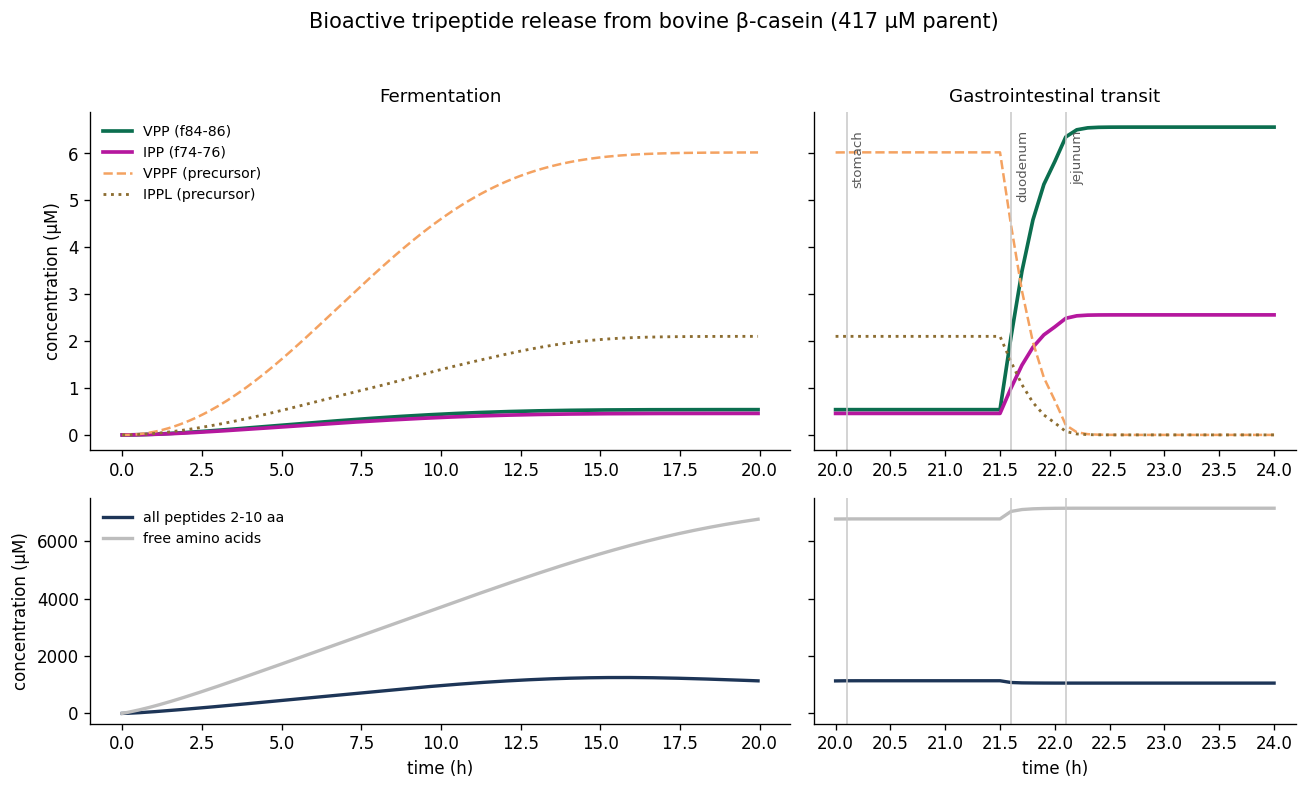

VPPF peaks at 6.023 µM during fermentation, then falls to 0.000 µM as PREP converts it;
VPP rises from 0.538 µM at the end of fermentation to 6.561 µM in the jejunum.


In [ ]:
# ---- Figure 1: release trajectory, split by process phase ------------------
# Fermentation occupies 20 h and gastrointestinal transit only 4 h, so plotting them on
# one axis compresses the phase where the tripeptides are actually liberated. Two panels
# with a shared y-axis keep both legible.
t = hist.t_h.values
t_ferment_end = hist.loc[hist.compartment == "ferment", "t_h"].max()
gi = hist.t_h >= t_ferment_end
bounds, seen = [], None
for tt, cc in zip(hist.t_h, hist.compartment):
    if cc != seen:
        bounds.append((tt, cc)); seen = cc

fig, axes = plt.subplots(2, 2, figsize=(11.0, 6.6), sharey="row",
                         gridspec_kw={"width_ratios": [1.45, 1.0],
                                      "height_ratios": [1.5, 1.0]})
series = [("VPP", PAL["vpp"], "-", 2.2, "VPP (f84-86)"),
          ("IPP", PAL["ipp"], "-", 2.2, "IPP (f74-76)"),
          ("VPPF", PAL["precursor"], "--", 1.5, "VPPF (precursor)"),
          ("IPPL", "#8C6D31", ":", 1.7, "IPPL (precursor)")]

for col, (mask, label) in enumerate([(~gi, "Fermentation"), (gi, "Gastrointestinal transit")]):
    ax = axes[0, col]
    for name, c, ls, lw, lab in series:
        ax.plot(t[mask], hist[name][mask], color=c, ls=ls, lw=lw,
                label=lab if col == 0 else None)
    ax.set_title(label, fontsize=11)
    if col == 0:
        ax.set_ylabel("concentration (µM)")
        ax.legend(frameon=False, fontsize=8.5, loc="upper left")

    ax2 = axes[1, col]
    ax2.plot(t[mask], hist.peptide_uM[mask], color=PAL["accent"], lw=2.0,
             label="all peptides 2-10 aa" if col == 0 else None)
    ax2.plot(t[mask], hist.free_aa_uM[mask], color=PAL["aa"], lw=2.0,
             label="free amino acids" if col == 0 else None)
    ax2.set_xlabel("time (h)")
    if col == 0:
        ax2.set_ylabel("concentration (µM)")
        ax2.legend(frameon=False, fontsize=8.5, loc="upper left")

# compartment boundaries, labelled once each inside the panel they belong to
for tt, cc in bounds:
    if cc in ("start", "ferment"):
        continue
    for row in (0, 1):
        axes[row, 1].axvline(tt, color="0.78", lw=0.9)
    axes[0, 1].annotate(cc, xy=(tt, 1.0), xycoords=("data", "axes fraction"),
                        xytext=(3, -11), textcoords="offset points",
                        fontsize=8, color="0.35", rotation=90, va="top")

fig.suptitle("Bioactive tripeptide release from bovine β-casein (417 µM parent)",
             fontsize=12.5, y=0.99)
fig.tight_layout(rect=(0, 0, 1, 0.965))
fig.savefig("figures/layer1_fig1_release_trajectory.png", bbox_inches="tight")
plt.show()

print(f"VPPF peaks at {hist.VPPF.max():.3f} µM during fermentation, then falls to "
      f"{hist.VPPF.iloc[-1]:.3f} µM as PREP converts it;")
print(f"VPP rises from {hist.loc[~gi,'VPP'].iloc[-1]:.3f} µM at the end of fermentation "
      f"to {hist.VPP.iloc[-1]:.3f} µM in the jejunum.")

---

# 5. Virtual cohort — where does inter-individual variation come from?

Eleven factors are varied by Latin-hypercube sampling: relative abundance of the three
species, community growth capacity, PepX/PepN/PepO gene dosage, fermentation duration,
gastric pH, intestinal transit, and host prolyl endopeptidase activity. PREP is included
deliberately — Section 3 predicted it performs the liberating cut, so this is a test of
that prediction rather than a generic parameter sweep.

In [ ]:
def sample_cohort(n, seed=SEED):
    """Latin-hypercube panel of virtual individuals."""
    rng = np.random.default_rng(seed)
    d = 11
    cut = np.linspace(0, 1, n + 1)
    u = cut[:n, None] + rng.random((n, d)) / n
    for j in range(d):
        u[:, j] = rng.permutation(u[:, j])
    cfgs = []
    for i in range(n):
        w = np.array([0.15 + 0.85 * u[i, 0], 0.15 + 0.85 * u[i, 1], 0.15 + 0.85 * u[i, 2]])
        w /= w.sum()
        cfgs.append({"subject": f"S{i+1:02d}", "inoculum": w.tolist(),
                     "mu_scale": float(np.exp(np.log(1.5) * (2 * u[i, 3] - 1))),
                     "copy_scale": {"PepX": float(np.exp(np.log(3.0) * (2 * u[i, 4] - 1))),
                                    "PepN": float(np.exp(np.log(3.0) * (2 * u[i, 5] - 1))),
                                    "PepO": float(np.exp(np.log(3.0) * (2 * u[i, 6] - 1)))},
                     "ferment_h": float(8.0 + 28.0 * u[i, 7]),
                     "gastric_pH": float(1.4 + 2.2 * u[i, 8]),
                     "transit_scale": float(0.6 + 1.2 * u[i, 9]),
                     "host_scale": {"pepsin": 1.0, "pancreatic": 1.0, "brushborder": 1.0,
                                    "prep": float(np.exp(np.log(4.0) * (2 * u[i, 10] - 1)))}})
    return cfgs


rows, peptidome = [], []
for cfg in sample_cohort(N_SUBJECTS):
    o = run_subject(rules, cfg)
    fs = o["final_state_uM"]
    h = pd.DataFrame(o["history"])
    rows.append({"subject": cfg["subject"], "ferment_pH": o["ferment_pH"],
                 "ferment_h": cfg["ferment_h"], "gastric_pH": cfg["gastric_pH"],
                 "transit_scale": cfg["transit_scale"], "mu_scale": cfg["mu_scale"],
                 "prep_scale": cfg["host_scale"]["prep"],
                 "pepX_scale": cfg["copy_scale"]["PepX"],
                 "pepN_scale": cfg["copy_scale"]["PepN"],
                 "pepO_scale": cfg["copy_scale"]["PepO"],
                 "frac_helveticus": cfg["inoculum"][0], "frac_lactis": cfg["inoculum"][1],
                 "frac_thermophilus": cfg["inoculum"][2],
                 "VPP_ferment_uM": float(h.loc[h.compartment == "ferment", "VPP"].iloc[-1]),
                 "IPP_ferment_uM": float(h.loc[h.compartment == "ferment", "IPP"].iloc[-1]),
                 "VPP_lumen_uM": fs.get("VPP", 0.0), "IPP_lumen_uM": fs.get("IPP", 0.0),
                 "balance": o["residue_mass_balance"]})
    for s, c in fs.items():
        if 2 <= len(s) <= 8 and c > 0.05:
            peptidome.append({"subject": cfg["subject"], "peptide": s, "length": len(s),
                              "lumen_uM": c})
    print(f"  {cfg['subject']}  VPP={fs.get('VPP',0):6.3f}  IPP={fs.get('IPP',0):6.3f} µM", flush=True)

cohort = pd.DataFrame(rows)
pepdf = pd.DataFrame(peptidome)
assert np.allclose(cohort.balance, 1.0, atol=1e-9), "mass balance violated"
print(f"\nresidue mass balance across cohort: "
      f"{cohort.balance.min():.12f} to {cohort.balance.max():.12f}")

summary = pd.DataFrame({
    c: {"median": cohort[c].median(), "min": cohort[c].min(), "max": cohort[c].max(),
        "fold range": cohort[c].max() / cohort[c].min()}
    for c in ["VPP_ferment_uM", "IPP_ferment_uM", "VPP_lumen_uM", "IPP_lumen_uM"]}).T
display(summary.round(3))

  S01  VPP= 5.922  IPP= 1.553 µM
  S02  VPP= 6.387  IPP= 3.834 µM
  S03  VPP= 6.462  IPP= 1.731 µM
  S04  VPP=11.603  IPP= 6.754 µM
  S05  VPP= 7.616  IPP= 2.868 µM
  S06  VPP= 7.673  IPP= 3.475 µM
  S07  VPP=37.509  IPP=34.358 µM
  S08  VPP=12.957  IPP= 8.118 µM
  S09  VPP=13.292  IPP= 6.519 µM
  S10  VPP=14.670  IPP= 8.146 µM
  S11  VPP=18.178  IPP=13.094 µM
  S12  VPP= 5.197  IPP= 1.906 µM
  S13  VPP= 4.533  IPP= 1.428 µM
  S14  VPP=19.832  IPP=13.351 µM
  S15  VPP= 5.839  IPP= 1.274 µM
  S16  VPP= 5.986  IPP= 1.655 µM

residue mass balance across cohort: 1.000000000000 to 1.000000000000


,median,min,max,fold range
VPP_ferment_uM,0.629,0.172,1.789,10.407
IPP_ferment_uM,0.613,0.109,1.322,12.117
VPP_lumen_uM,7.644,4.533,37.509,8.275
IPP_lumen_uM,3.655,1.274,34.358,26.976


### Why not rank correlations across the cohort?

The obvious analysis — Spearman ρ between each sampled factor and the luminal dose — is
**underpowered here and gives unstable answers**. With 11 factors varied simultaneously
and a cohort in the tens, the Latin-hypercube design leaves the factors partially
confounded, and re-running at a different cohort size can flip the sign of a
coefficient. That is a property of the design, not of the biology, and a driver ranking
that changes when you change `N_SUBJECTS` is not a finding.

Because Layer 1 is fully **deterministic**, there is a better estimator available at
similar cost: a one-at-a-time sweep. Each factor is varied across its range while the
others are held at the reference configuration, giving an unambiguous response curve per
factor. This trades the ability to detect interactions for the ability to make a clean
causal statement about each factor in isolation — the right trade when the question is
"does host prolyl endopeptidase activity increase tripeptide release?"

The cohort above is still the right tool for the **spread**, which needs factors varying
together; it is simply the wrong tool for attribution at this sample size.

In [ ]:
# ---- one-at-a-time sensitivity sweep (deterministic) ----------------------
OAT_LEVELS = 5
OAT_FACTORS = {
    # factor -> (how to apply it to a config, multiplicative levels)
    "prep_scale":  ("host_scale.prep", np.logspace(-np.log10(4), np.log10(4), OAT_LEVELS)),
    "pepO_scale":  ("copy_scale.PepO", np.logspace(-np.log10(3), np.log10(3), OAT_LEVELS)),
    "pepX_scale":  ("copy_scale.PepX", np.logspace(-np.log10(3), np.log10(3), OAT_LEVELS)),
    "pepN_scale":  ("copy_scale.PepN", np.logspace(-np.log10(3), np.log10(3), OAT_LEVELS)),
    "transit_scale": ("transit_scale", np.linspace(0.6, 1.8, OAT_LEVELS)),
}


def apply_factor(cfg, path, value):
    cfg = {**cfg, "copy_scale": dict(cfg["copy_scale"]), "host_scale": dict(cfg["host_scale"])}
    if "." in path:
        grp, key = path.split(".")
        cfg[grp][key] = float(value)
    else:
        cfg[path] = float(value)
    return cfg


oat_rows = []
for factor, (path, levels) in OAT_FACTORS.items():
    for lv in levels:
        o = run_subject(rules, apply_factor(REF, path, lv))
        fs = o["final_state_uM"]
        oat_rows.append({"factor": factor, "level": float(lv),
                         "VPP_lumen_uM": fs.get("VPP", 0.0), "IPP_lumen_uM": fs.get("IPP", 0.0)})
    print(f"  swept {factor} ({OAT_LEVELS} levels)", flush=True)
oat = pd.DataFrame(oat_rows)

# effect size = log2 fold change from the lowest to the highest level of each factor
eff = []
for factor, g in oat.groupby("factor"):
    g = g.sort_values("level")
    for pep in ("VPP", "IPP"):
        lo, hi = g[f"{pep}_lumen_uM"].iloc[0], g[f"{pep}_lumen_uM"].iloc[-1]
        eff.append({"factor": factor, "peptide": pep, "low_level_uM": lo, "high_level_uM": hi,
                    "log2_fold": np.log2(hi / lo) if lo > 0 and hi > 0 else np.nan,
                    "direction": "increases release" if hi > lo else "decreases release"})
eff = pd.DataFrame(eff)
eff["abs_log2"] = eff.log2_fold.abs()
display(eff.sort_values("abs_log2", ascending=False).round(3).reset_index(drop=True))
print("Effect size is the log2 fold change in luminal concentration from the lowest to the")
print("highest level of each factor, with all other factors held at the reference values.")

  swept prep_scale (5 levels)
  swept pepO_scale (5 levels)
  swept pepX_scale (5 levels)
  swept pepN_scale (5 levels)
  swept transit_scale (5 levels)


,factor,peptide,low_level_uM,high_level_uM,log2_fold,direction,abs_log2
0,pepO_scale,IPP,14.516,2.004,-2.857,decreases release,2.857
1,pepO_scale,VPP,17.863,6.887,-1.375,decreases release,1.375
2,pepN_scale,VPP,13.424,7.527,-0.835,decreases release,0.835
3,pepN_scale,IPP,6.653,4.247,-0.648,decreases release,0.648
4,pepX_scale,IPP,2.882,2.097,-0.459,decreases release,0.459
5,pepX_scale,VPP,7.323,6.438,-0.186,decreases release,0.186
6,prep_scale,VPP,6.554,6.561,0.002,increases release,0.002
7,prep_scale,IPP,2.556,2.558,0.001,increases release,0.001
8,transit_scale,VPP,6.561,6.561,0.000,increases release,0.000
9,transit_scale,IPP,2.558,2.558,0.000,increases release,0.000


Effect size is the log2 fold change in luminal concentration from the lowest to the
highest level of each factor, with all other factors held at the reference values.


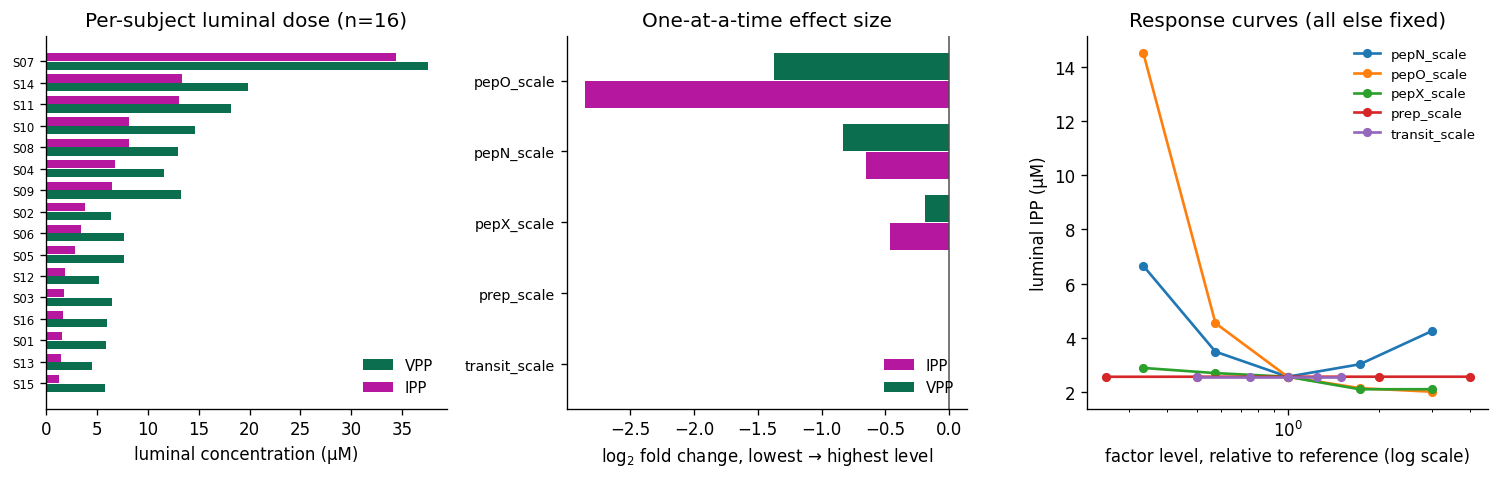

In [ ]:
# ---- Figure 2: cohort spread and driver attribution ------------------------
fig, axes = plt.subplots(1, 3, figsize=(12.6, 4.1))

ax = axes[0]
xs = np.arange(len(cohort))
order = cohort.sort_values("IPP_lumen_uM").reset_index(drop=True)
ax.barh(xs - 0.2, order.VPP_lumen_uM, height=0.38, color=PAL["vpp"], label="VPP")
ax.barh(xs + 0.2, order.IPP_lumen_uM, height=0.38, color=PAL["ipp"], label="IPP")
ax.set_yticks(xs); ax.set_yticklabels(order.subject, fontsize=7)
ax.set_xlabel("luminal concentration (µM)")
ax.set_title(f"Per-subject luminal dose (n={len(cohort)})")
ax.legend(frameon=False)

ax = axes[1]
o2 = (eff[eff.peptide == "IPP"].set_index("factor")
      .join(eff[eff.peptide == "VPP"].set_index("factor"), rsuffix="_vpp")
      .sort_values("abs_log2"))
y = np.arange(len(o2))
ax.barh(y - 0.2, o2.log2_fold, height=0.38, color=PAL["ipp"], label="IPP")
ax.barh(y + 0.2, o2.log2_fold_vpp, height=0.38, color=PAL["vpp"], label="VPP")
ax.axvline(0, color="0.3", lw=0.9)
ax.set_yticks(y); ax.set_yticklabels(o2.index, fontsize=8.5)
ax.set_xlabel("log$_2$ fold change, lowest → highest level")
ax.set_title("One-at-a-time effect size")
ax.legend(frameon=False, loc="lower right")

ax = axes[2]
for factor, g in oat.groupby("factor"):
    g = g.sort_values("level")
    norm = g.level / g.level.median()
    ax.plot(norm, g.IPP_lumen_uM, marker="o", ms=4.5, lw=1.6, label=factor)
ax.set_xscale("log")
ax.set_xlabel("factor level, relative to reference (log scale)")
ax.set_ylabel("luminal IPP (µM)")
ax.set_title("Response curves (all else fixed)")
ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig("figures/layer1_fig2_cohort_drivers.png", bbox_inches="tight")
plt.show()

In [ ]:
# ---- state the conclusion from the computed sweep, not from expectation ----
piv = eff.pivot(index="factor", columns="peptide", values="log2_fold")
ranked = piv.assign(mean_abs=piv.abs().mean(axis=1)).sort_values("mean_abs", ascending=False)
top = ranked.index[0]
pepx = float(ranked.loc["pepX_scale", "mean_abs"])
print("factors ranked by mean |log2 fold change| in luminal concentration:")
for f, r in ranked.iterrows():
    print(f"   {f:15s} VPP {r['VPP']:+.2f}   IPP {r['IPP']:+.2f}   |mean| {r['mean_abs']:.2f}")
print(f"\nstrongest factor: {top}")
print(f"PepX gene dosage effect: {pepx:.2f} log2 units "
      f"({'negligible' if pepx < 0.5 else 'substantial'})")
print(f"spread across the {len(cohort)}-subject cohort: "
      f"VPP {cohort.VPP_lumen_uM.min():.2f}-{cohort.VPP_lumen_uM.max():.2f} uM "
      f"({cohort.VPP_lumen_uM.max()/cohort.VPP_lumen_uM.min():.1f}-fold), "
      f"IPP {cohort.IPP_lumen_uM.min():.2f}-{cohort.IPP_lumen_uM.max():.2f} uM "
      f"({cohort.IPP_lumen_uM.max()/cohort.IPP_lumen_uM.min():.1f}-fold)")

factors ranked by mean |log2 fold change| in luminal concentration:
   pepO_scale      VPP -1.37   IPP -2.86   |mean| 2.12
   pepN_scale      VPP -0.83   IPP -0.65   |mean| 0.74
   pepX_scale      VPP -0.19   IPP -0.46   |mean| 0.32
   prep_scale      VPP +0.00   IPP +0.00   |mean| 0.00
   transit_scale   VPP +0.00   IPP +0.00   |mean| 0.00

strongest factor: pepO_scale
PepX gene dosage effect: 0.32 log2 units (negligible)
spread across the 16-subject cohort: VPP 4.53-37.51 uM (8.3-fold), IPP 1.27-34.36 uM (27.0-fold)


**How to read the two analyses together.** The cohort establishes that the luminal dose
varies severalfold across plausible individuals — that is a claim about spread, and it is
robust because it only requires the factors to vary together. The sweep establishes
*which* factors do the work, and it is the analysis to quote for attribution, because it
is deterministic rather than a correlation over a small confounded design.

**What the sweep found, and why it is not what one would guess.** The factors that control
the luminal dose are the bacterial peptidases that *consume the precursor pool during
fermentation* — PepO first, PepN second. Two results are worth dwelling on because both
contradict a plausible prior:

- **PepX gene dosage is nearly irrelevant**, even though it is the enzyme whose
  specificity defines the whole Xaa-Pro-Pro story. It cannot touch the tripeptide, and its
  effect on the precursors is small. A twin that personalises on PepX abundance would be
  personalising on the wrong variable.
- **Host prolyl endopeptidase activity has essentially no effect either**, despite being
  the enzyme that performs the liberating cut. Its response curve is flat. The reason is
  informative rather than disappointing: at the reference configuration the conversion of
  VPPF/IPPL to VPP/IPP **runs to completion within jejunal residence time**, so the
  reaction is not rate-limited by PREP activity. Varying PREP fourfold in either direction
  changes only how fast a reaction that finishes anyway gets there.

The distinction that matters is therefore **structural versus rate-limiting**. Prolyl
endopeptidase is *in the causal path* — remove it and no intact tripeptide is released at
all, as Section 3 shows — but it is *not a source of variation* at plausible activity
levels. That is a sharper and more useful statement than a correlation coefficient, and it
carries a concrete prediction: PREP would only become a personalising factor in
individuals whose activity falls far enough below the assumed reference to stop saturating
the conversion, which is a measurable threshold rather than a trend.

The numeric ranking is printed above rather than asserted here, because it depends on the
assumed reference configuration and on sweep ranges that are themselves assumptions. Read
it as the model's internal ordering, not as measured biology.

---

# 6. The luminal peptidome — and a result that reframes the project

Up to this point the analysis has followed the lactotripeptides because that is what the
literature follows. But the model tracks every species, so it can be asked what the lumen
*actually* contains.

In [ ]:
pep_u = (pepdf.groupby("peptide")
         .agg(mean_uM=("lumen_uM", "mean"), min_uM=("lumen_uM", "min"),
              max_uM=("lumen_uM", "max"), n_subjects=("subject", "nunique"))
         .reset_index())
pep_u["length"] = pep_u.peptide.str.len()


def pep_class(p):
    """Classify by motif, not just by length.

    Xaa-Pro-Pro is kept as its own class because that motif -- not the specific VPP/IPP
    sequences -- is what confers the proteolytic resistance established in Section 2. Any
    Xaa-Pro-Pro the model produces is a lactotripeptide analogue and belongs with them.
    """
    if len(p) == 3 and p[1] == "P" and p[2] == "P":
        return "Xaa-Pro-Pro tripeptide"
    if len(p) == 2 and p[1] == "P":
        return "Xaa-Pro dipeptide"
    return "other"


pep_u["motif_class"] = pep_u.peptide.map(pep_class)
pep_u = pep_u.sort_values("mean_uM", ascending=False).reset_index(drop=True)
display(pep_u.round(3))

tot = pep_u.mean_uM.sum()
by_class = pep_u.groupby("motif_class").mean_uM.sum()
vpp_mean = float(pep_u.loc[pep_u.peptide == "VPP", "mean_uM"].iloc[0])
xp = float(by_class.get("Xaa-Pro dipeptide", 0.0))
xpp = float(by_class.get("Xaa-Pro-Pro tripeptide", 0.0))
print(f"total luminal peptide (2-8 aa, >0.05 µM)   {tot:8.1f} µM")
for k, v in by_class.sort_values(ascending=False).items():
    print(f"  {k:26s} {v:8.1f} µM  ({v/tot:5.1%})")
print(f"\nXaa-Pro dipeptides outnumber the whole Xaa-Pro-Pro class by {xp/xpp:.0f}-fold,")
print(f"and outnumber VPP alone by {xp/vpp_mean:.0f}-fold, on a molar basis.")
xpp_members = pep_u.loc[pep_u.motif_class == "Xaa-Pro-Pro tripeptide", "peptide"].tolist()
print(f"\nXaa-Pro-Pro peptides the model produces: {', '.join(xpp_members)}")
print("Any of these inherits the same proteolytic-resistance mechanism as VPP and IPP;")
print("those beyond VPP/IPP are untested candidates rather than established bioactives.")

,peptide,mean_uM,min_uM,max_uM,n_subjects,length,motif_class
0,GP,383.797,245.114,572.172,16,2,Xaa-Pro dipeptide
1,FP,225.752,142.907,361.303,16,2,Xaa-Pro dipeptide
2,VP,167.138,93.846,318.792,16,2,Xaa-Pro dipeptide
3,EP,129.236,84.413,246.312,16,2,Xaa-Pro dipeptide
4,YP,75.454,34.682,220.613,16,2,Xaa-Pro dipeptide
5,LP,68.687,28.076,242.727,16,2,Xaa-Pro dipeptide
6,MP,44.952,17.338,163.457,16,2,Xaa-Pro dipeptide
7,QP,34.153,7.511,168.874,16,2,Xaa-Pro dipeptide
8,HP,22.248,5.807,59.069,16,2,Xaa-Pro dipeptide
9,IP,17.284,5.579,45.031,16,2,Xaa-Pro dipeptide


total luminal peptide (2-8 aa, >0.05 µM)     1234.2 µM
  Xaa-Pro dipeptide            1190.4 µM  (96.4%)
  Xaa-Pro-Pro tripeptide         43.5 µM  ( 3.5%)
  other                           0.3 µM  ( 0.0%)

Xaa-Pro dipeptides outnumber the whole Xaa-Pro-Pro class by 27-fold,
and outnumber VPP alone by 104-fold, on a molar basis.

Xaa-Pro-Pro peptides the model produces: FPP, VPP, LPP, IPP
Any of these inherits the same proteolytic-resistance mechanism as VPP and IPP;
those beyond VPP/IPP are untested candidates rather than established bioactives.


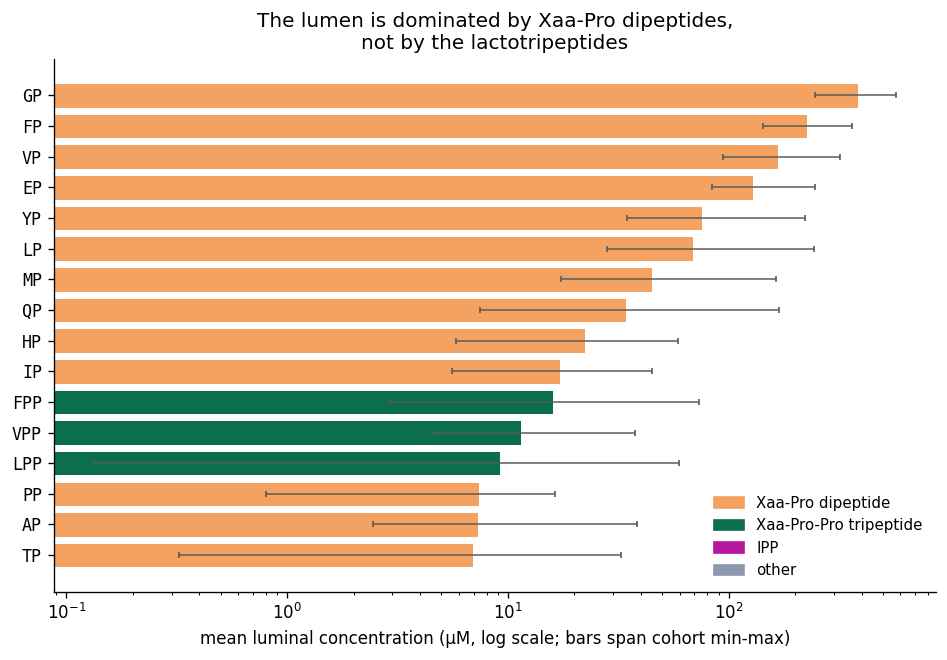

In [ ]:
# ---- Figure 3: what the lumen actually contains ---------------------------
top = pep_u.head(16).iloc[::-1]
CLASS_COLOR = {"Xaa-Pro dipeptide": PAL["precursor"],
               "Xaa-Pro-Pro tripeptide": PAL["vpp"], "other": PAL["other"]}
colors = [PAL["ipp"] if p == "IPP" else CLASS_COLOR[k]
          for p, k in zip(top.peptide, top.motif_class)]
fig, ax = plt.subplots(figsize=(8.0, 5.6))
y = np.arange(len(top))
ax.barh(y, top.mean_uM, color=colors, edgecolor="white", linewidth=0.6)
ax.errorbar(top.mean_uM, y, xerr=[top.mean_uM - top.min_uM, top.max_uM - top.mean_uM],
            fmt="none", ecolor="0.35", elinewidth=0.9, capsize=2)
ax.set_yticks(y); ax.set_yticklabels(top.peptide, fontfamily="monospace")
ax.set_xscale("log")
ax.set_xlabel("mean luminal concentration (µM, log scale; bars span cohort min-max)")
ax.set_title("The lumen is dominated by Xaa-Pro dipeptides,\nnot by the lactotripeptides",
             fontsize=12)
handles = [plt.Rectangle((0, 0), 1, 1, color=PAL["precursor"]),
           plt.Rectangle((0, 0), 1, 1, color=PAL["vpp"]),
           plt.Rectangle((0, 0), 1, 1, color=PAL["ipp"]),
           plt.Rectangle((0, 0), 1, 1, color=PAL["other"])]
ax.legend(handles, ["Xaa-Pro dipeptide", "Xaa-Pro-Pro tripeptide", "IPP", "other"],
          frameon=False, loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig("figures/layer1_fig3_peptidome.png", bbox_inches="tight")
plt.show()

**The lactotripeptides are a minor component of their own peptidome.** The dominant
species are Xaa-Pro dipeptides, produced by exactly the PepX/DPP-IV chemistry that spares
the tripeptides — the enzymes release Xaa-Pro dipeptides wherever the following residue is
*not* Pro, which across β-casein's 35 prolines is most places.

Why this matters for Layers 2 and 3:

- **Layer 2.** Dipeptides are the canonical PEPT1 substrate class. If their intestinal
  transport is even modestly more efficient than that of an Xaa-Pro-Pro tripeptide, their
  systemic concentrations could exceed the lactotripeptides' by orders of magnitude. The
  retrieved evidence cannot settle this: all PEPT1 kinetics in the dossier are on
  dipeptide reporters (Gly-Sar, Gly-Gln), with **no side-by-side dipeptide-versus-
  tripeptide comparison**, so the transport advantage must be treated as a parameter to
  bound rather than a known quantity.
- **Layer 3.** Several Xaa-Pro and Xaa-aromatic dipeptides are genuinely potent ACE
  inhibitors, and dipeptides make up 52 of the 73 sequences in the ACE potency training
  set — so scoring these is interpolation in the model's best-characterised regime, not
  extrapolation.

That makes the whole-peptidome hypothesis the most testable alternative to the
conventional VPP/IPP-only account, and it is testable with data already in hand.

---

# 7. Limitations, stated as specifications

Not a caveats paragraph — a list of what would have to be measured, ordered by how much it
would change the answer.

In [ ]:
limits = pd.DataFrame([
 {"#": 1, "limitation": "Bacterial PepO activity and specificity are family-level inferences",
  "consequence": "the sweep's strongest factor rests on an InterPro family assignment, not a documented activity",
  "measurement that would resolve it": "PepO cleavage-site mapping on beta-casein fragments for the strains used",
  "priority": "highest"},
 {"#": 2, "limitation": "Host prolyl endopeptidase activity in duodenum/jejunum is assumed",
  "consequence": "the liberating cut is structurally essential; the sweep shows it is saturating, so the assumed level sets whether that remains true",
  "measurement that would resolve it": "PREP activity assay on human intestinal mucosa / luminal fluid, to test whether physiological activity is above the saturating threshold",
  "priority": "high"},
 {"#": 3, "limitation": "Cell-envelope proteinase rules (PrtH, PrtH2, PrtB, PrtS) are placeholders",
  "consequence": "the first proteolytic step has no documented specificity for 4 of 5 strains",
  "measurement that would resolve it": "peptidomics of single-strain casein fermentations (LC-MS/MS)",
  "priority": "high"},
 {"#": 4, "limitation": "No kinetic constant was measured on VPP, IPP or intact casein",
  "consequence": "absolute concentrations are internal arithmetic, not predictions with error bars",
  "measurement that would resolve it": "kcat/Km for PepX, PepN, PepO, PREP on defined casein peptides",
  "priority": "high"},
 {"#": 5, "limitation": "Luminal enzyme concentrations are assumed throughout",
  "consequence": "sets the absolute timescale of every compartment",
  "measurement that would resolve it": "activity-based quantification in aspirated human intestinal fluid",
  "priority": "high"},
 {"#": 6, "limitation": "No measured luminal or mucosal peptide concentrations exist in the dossier",
  "consequence": "Layer 1 output cannot be validated against data at its own boundary",
  "measurement that would resolve it": "targeted LC-MS/MS of VPP/IPP and Xaa-Pro dipeptides in intestinal aspirate",
  "priority": "highest"},
 {"#": 7, "limitation": "Evidence base is 95% abstract-sourced; PMC extraction stripped numeric tables",
  "consequence": "some retrievable kinetics were missed rather than absent",
  "measurement that would resolve it": "manual full-text extraction of the 62 retrieved PMC articles",
  "priority": "medium"},
 {"#": 8, "limitation": "Tier A is a logistic surrogate, not a community GEM",
  "consequence": "enzyme dosage ignores metabolic cross-feeding and substrate competition",
  "measurement that would resolve it": "swap in AGORA2 + MICOM via the existing enzyme_activities() interface",
  "priority": "medium"},
 {"#": 9, "limitation": "Only bovine beta-casein is simulated",
  "consequence": "alpha-S1/alpha-S2/kappa-casein and whey contributions to the peptidome are omitted",
  "measurement that would resolve it": "none needed - run the same engine over the other embedded sequences",
  "priority": "low (compute, not evidence)"},
])
display(limits.set_index("#"))
print("Items 1 and 6 would change conclusions rather than refine numbers: item 1 because")
print("the sweep's strongest factor has no documented catalytic activity, and item 6")
print("because Layer 1 currently cannot be validated at its own output boundary.")

,limitation,consequence,measurement that would resolve it,priority
#,,,,
1,Bacterial PepO activity and specificity are family-level inferences,the sweep's strongest factor rests on an InterPro family assignmen...,PepO cleavage-site mapping on beta-casein fragments for the strain...,highest
2,Host prolyl endopeptidase activity in duodenum/jejunum is assumed,the liberating cut is structurally essential; the sweep shows it i...,"PREP activity assay on human intestinal mucosa / luminal fluid, to...",high
3,"Cell-envelope proteinase rules (PrtH, PrtH2, PrtB, PrtS) are place...",the first proteolytic step has no documented specificity for 4 of ...,peptidomics of single-strain casein fermentations (LC-MS/MS),high
4,"No kinetic constant was measured on VPP, IPP or intact casein","absolute concentrations are internal arithmetic, not predictions w...","kcat/Km for PepX, PepN, PepO, PREP on defined casein peptides",high
5,Luminal enzyme concentrations are assumed throughout,sets the absolute timescale of every compartment,activity-based quantification in aspirated human intestinal fluid,high
6,No measured luminal or mucosal peptide concentrations exist in the...,Layer 1 output cannot be validated against data at its own boundary,targeted LC-MS/MS of VPP/IPP and Xaa-Pro dipeptides in intestinal ...,highest
7,Evidence base is 95% abstract-sourced; PMC extraction stripped num...,some retrievable kinetics were missed rather than absent,manual full-text extraction of the 62 retrieved PMC articles,medium
8,"Tier A is a logistic surrogate, not a community GEM",enzyme dosage ignores metabolic cross-feeding and substrate compet...,swap in AGORA2 + MICOM via the existing enzyme_activities() interface,medium
9,Only bovine beta-casein is simulated,alpha-S1/alpha-S2/kappa-casein and whey contributions to the pepti...,none needed - run the same engine over the other embedded sequences,"low (compute, not evidence)"


Items 1 and 6 would change conclusions rather than refine numbers: item 1 because
the sweep's strongest factor has no documented catalytic activity, and item 6
because Layer 1 currently cannot be validated at its own output boundary.


---

# 8. Handoff to Layer 2

Layer 1 delivers, per virtual individual, a time-resolved luminal concentration for every
peptide species. That is Layer 2's input, and the two numbers it must carry forward are
the per-subject luminal doses and their spread.

**What Layer 1 establishes**

1. The proteolytic stability of VPP and IPP is *derived* from documented specificity, not
   fitted — no enzyme in a 36-rule panel can cleave either, while the control VPL is cut.
2. The release route runs through aminopeptidase stall at VPPF/IPPL followed by a
   prolyl-endopeptidase cut, making a **host** enzyme the rate-determining step.
3. The luminal dose varies severalfold across plausible individuals, and the sweep shows
   the variation is controlled by the bacterial peptidases that consume the **precursor
   pool** (PepO, then PepN) — not by PepX, and not by host prolyl endopeptidase, whose
   liberating cut is structurally essential but saturating and therefore not a source of
   variation. The numeric ranking is printed by the notebook rather than quoted here,
   since it depends on assumed ranges.
4. The lumen is dominated by Xaa-Pro dipeptides at roughly two orders of magnitude above
   the lactotripeptides, which is the most promising untested mechanism in the project.
5. The reaction network conserves residue mass to machine precision, so the arithmetic is
   verifiable even where the parameters are not.

**What Layer 1 cannot establish:** any absolute concentration, because 1 of 29 kinetic
parameter sets is a measurement on the right enzyme and substrate.

**What Layer 2 then does with this.** Luminal presence is not systemic availability. The
measured facts waiting there are stark: IPP's Caco-2 apparent permeability is 1.0 × 10⁻⁸
cm/s, its absolute oral bioavailability is 0.077–0.38 % in pig, and its human plasma Cmax
is 897 pmol/L. Against an ACE-inhibitory IC50 of 5 µM, that Cmax corresponds to a peak
systemic ACE occupancy of **1.8 × 10⁻⁴** — while trials report −2.6 to −5 mmHg systolic.
Layer 2 is where that gap is quantified, and Layer 3 is where it has to be explained.

In [ ]:
# ---- export for Layer 2 ---------------------------------------------------
cohort.to_csv("layer1_cohort_summary.csv", index=False)
pep_u.to_csv("layer1_peptidome.csv", index=False)
hist.to_csv("layer1_reference_trajectory.csv", index=False)
vres.to_csv("layer1_rule_validation.csv", index=False)
oat.to_csv("layer1_oat_sweep.csv", index=False)
eff.to_csv("layer1_driver_effect_sizes.csv", index=False)
print("written:")
for f in sorted(os.listdir(".")):
    if f.startswith("layer1_") and f.endswith(".csv"):
        print("   ", f, f"({os.path.getsize(f)/1024:.1f} KB)")
print("\nfigures:")
for f in sorted(os.listdir("figures")):
    print("   figures/" + f)

written:
    layer1_cohort_summary.csv (5.3 KB)
    layer1_driver_effect_sizes.csv (1.1 KB)
    layer1_oat_sweep.csv (1.5 KB)
    layer1_peptidome.csv (1.7 KB)
    layer1_reference_trajectory.csv (37.8 KB)
    layer1_rule_validation.csv (0.7 KB)

figures:
   figures/layer1_fig1_release_trajectory.png
   figures/layer1_fig2_cohort_drivers.png
   figures/layer1_fig3_peptidome.png
